# TFM — Spectral Analysis of the OECD Inter-Country Input-Output System, 1995–2022
**Adrián Fernández Ciruelos** · Master in Quantitative Economic Analysis, UAM

Notebook reorganizado siguiendo el orden de la Sección 4 (Metodología) del TFM. Cada sección indica entre paréntesis a qué apartado de la metodología y de resultados corresponde.

**Cómo usar este notebook:** ajusta `DATA_DIR` en la Sección 0 a la carpeta donde tengas los CSV del ICIO 2025, y ejecuta las secciones en orden. Cada sección genera las figuras citadas en el TFM directamente en `figures/`.


## 0. Configuración e imports

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse.linalg as spla
import scipy.linalg as sla
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import spsolve, eigsh
from scipy.stats import shapiro, norm
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

# Gráficos inline
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ─── AJUSTA ESTA RUTA ─────────────────────────────────────────────────────────
DATA_DIR = r"C:\Users\adria\Desktop\MASTER\SOCIAL NETWORKS\proyecto\datos"
YEARS = list(range(1995, 2022))
years_sorted = YEARS  # alias usado en varias celdas del desarrollo original

# Parámetros globales
N_LOUVAIN_RUNS = 50      # ejecuciones de Louvain para consensus clustering
KEY_YEARS      = [1995, 2000, 2008, 2016, 2019, 2022]
shocks = {2001: "Dotcom", 2008: "GFC", 2018: "Trade tensions", 2020: "COVID-19"}

# ─── CARPETA DE SALIDA ─────────────────────────────────────────────────────────
# Se llama "figures" a propósito: coincide con la carpeta que usas en Overleaf
# en los \includegraphics{figures/...}. Cuando termines de ejecutar el
# notebook, solo tienes que arrastrar el contenido de esta carpeta entera a
# tu carpeta "figures" de Overleaf — sin renombrar nada, los nombres ya
# coinciden uno a uno con los que aparecen en el .tex.
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Carpeta de salida: {os.path.abspath(OUTPUT_DIR)}")

print(f"DATA_DIR: {DATA_DIR}")
print(f"Años: {YEARS[0]} — {YEARS[-1]} ({len(YEARS)} años)")

Carpeta de salida: c:\Users\adria\Downloads\figures
DATA_DIR: C:\Users\adria\Desktop\MASTER\SOCIAL NETWORKS\proyecto\datos
Años: 1995 — 2022 (28 años)


## 1. Carga de datos y construcción de A (Metodología §4.1)
Construimos las matrices **Z** (flujos intermedios), **A** (coeficientes técnicos), **x** (output total) e **y** (demanda final agregada) para cada año 1995–2022.

**Decisión metodológica:** no normalizamos las columnas de A que superan 1 — se verifica en la Sección 2 que los resultados espectrales son idénticos con y sin esa normalización, así que se deja A tal cual sale de los datos, documentando cuántas columnas y cuánto exceden la condición.

In [2]:
FINAL_DEMAND_KEYWORDS = ["HFCE", "NPISH", "GGFC", "GFCF", "INVNT", "DPABR"]
NON_PRODUCTIVE_ROWS   = ["TLS", "VA", "OUT"]

def _get_file_path(year):
    for name in [f"ICIO2025_{year}.csv", f"{year}.csv"]:
        path = os.path.join(DATA_DIR, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"No encontrado: {year} en {DATA_DIR}")

def _sector_cols(df):
    return [c for c in df.columns
            if not any(c.endswith(k) for k in FINAL_DEMAND_KEYWORDS)
            and c not in NON_PRODUCTIVE_ROWS and c != "OUT"]

def _sector_rows(df):
    return [i for i in df.index if i not in NON_PRODUCTIVE_ROWS]

def load_single_year(year):
    df = pd.read_csv(_get_file_path(year), index_col=0)
    s_rows = _sector_rows(df)
    s_cols = _sector_cols(df)
    Z = df.loc[s_rows, s_cols].astype(float)
    out_label = "OUT" if "OUT" in df.index else "OUTPUT"
    x = df.loc[out_label, s_cols].astype(float)
    fd_cols = [c for c in df.columns if any(c.endswith(k) for k in FINAL_DEMAND_KEYWORDS)]
    y = df.loc[s_rows, fd_cols].astype(float).sum(axis=1)
    return Z, x, y

def build_A(Z, x):
    """Construye A = Z / x por columnas. NO normaliza columnas > 1
    (instrucción de Sara) — solo lo registra para que quede documentado."""
    x_safe = x.copy().astype(float)
    x_safe[x_safe <= 0] = np.nan
    A = Z.div(x_safe, axis="columns").fillna(0.0).clip(lower=0.0)

    col_sums = A.sum(axis=0)
    bad = col_sums[col_sums > 1.0]
    if len(bad):
        print(f"  INFO (sin normalizar): {len(bad)} columnas > 1 "
              f"| máx={col_sums.max():.4f} | min_exceso={bad.min():.4f}")
    else:
        print(f"  INFO: todas las columnas cumplen condición Leontief (≤1)")

    return A

def build_node_labels(A_sample):
    labels = list(A_sample.index)
    countries, sectors = [], []
    for lbl in labels:
        parts = lbl.split("_", 1)
        if len(parts) == 2:
            c, s = parts
            if c not in countries: countries.append(c)
            if s not in sectors:   sectors.append(s)
    return countries, sectors, labels

# ── Bucle principal ───────────────────────────────────────────────────────────
Z_dict, A_dict, X_dict, Y_dict = {}, {}, {}, {}

for year in YEARS:
    try:
        Z, x, y = load_single_year(year)
        A       = build_A(Z, x)
        Z_dict[year] = Z
        A_dict[year] = A
        X_dict[year] = x
        Y_dict[year] = y
        col_sums_max = A.values.sum(axis=0).max()
        cols_over_1  = int((A.values.sum(axis=0) > 1).sum())
        print(f"✓ {year} | Z={Z.shape} | "
              f"max col_sum(A)={col_sums_max:.4f} | "
              f"cols>1: {cols_over_1}")
    except Exception as e:
        print(f"✗ {year}: {e}")

COUNTRIES, SECTORS, NODE_LABELS = build_node_labels(A_dict[min(A_dict)])
print(f"\nPaíses: {len(COUNTRIES)} | Sectores: {len(SECTORS)} | Nodos: {len(NODE_LABELS)}")

  INFO: todas las columnas cumplen condición Leontief (≤1)
✓ 1995 | Z=(4250, 4250) | max col_sum(A)=0.9914 | cols>1: 0
  INFO (sin normalizar): 1 columnas > 1 | máx=1.0028 | min_exceso=1.0028
✓ 1996 | Z=(4250, 4250) | max col_sum(A)=1.0028 | cols>1: 1
  INFO: todas las columnas cumplen condición Leontief (≤1)
✓ 1997 | Z=(4250, 4250) | max col_sum(A)=0.9985 | cols>1: 0
  INFO (sin normalizar): 1 columnas > 1 | máx=1.0002 | min_exceso=1.0002
✓ 1998 | Z=(4250, 4250) | max col_sum(A)=1.0002 | cols>1: 1
  INFO: todas las columnas cumplen condición Leontief (≤1)
✓ 1999 | Z=(4250, 4250) | max col_sum(A)=0.9944 | cols>1: 0
  INFO: todas las columnas cumplen condición Leontief (≤1)
✓ 2000 | Z=(4250, 4250) | max col_sum(A)=0.9797 | cols>1: 0
  INFO: todas las columnas cumplen condición Leontief (≤1)
✓ 2001 | Z=(4250, 4250) | max col_sum(A)=0.9708 | cols>1: 0
  INFO: todas las columnas cumplen condición Leontief (≤1)
✓ 2002 | Z=(4250, 4250) | max col_sum(A)=0.9802 | cols>1: 0
  INFO: todas las co

## 2. Viabilidad de Leontief — T1 (Metodología §4.2, Resultados §5.1)
La condición de viabilidad exige $\sum_i a_{ij} \leq 1$ para todo $j$. Comprobamos su cumplimiento y documentamos las excepciones.

In [3]:
records_T1 = []
for year, A in A_dict.items():
    rs = A.values.sum(axis=1)
    records_T1.append({"year": year, "min": rs.min(), "max": rs.max(),
                        "mean": rs.mean(), "std": rs.std()})

df_T1 = pd.DataFrame(records_T1).set_index("year")
display(df_T1.describe().round(4))

,min,max,mean,std
count,28.0,28.0000,28.0000,28.0000
mean,0.0,10.7315,0.4850,0.7621
std,0.0,1.4007,0.0068,0.0317
min,0.0,8.9799,0.4735,0.7193
25%,0.0,9.4028,0.4798,0.7284
50%,0.0,10.5556,0.4872,0.7710
75%,0.0,12.0304,0.4899,0.7884
max,0.0,12.9221,0.4968,0.8317


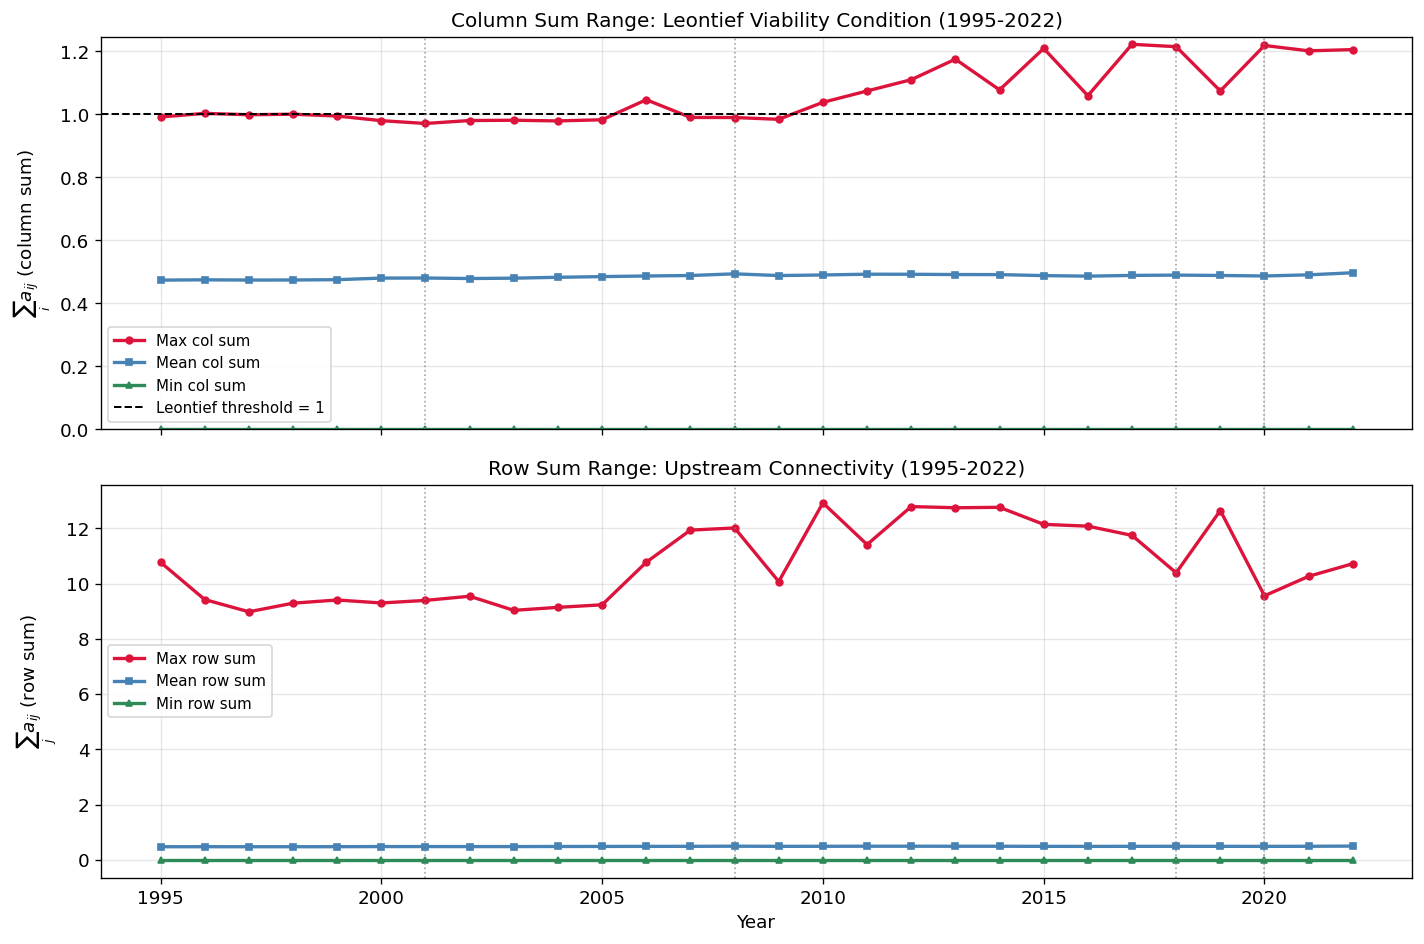

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: suma de COLUMNAS (condición Leontief — viabilidad)
col_records = []
for year, A in A_dict.items():
    cs = A.values.sum(axis=0)
    col_records.append({"year": year, "min": cs.min(),
                         "max": cs.max(), "mean": cs.mean()})
df_cols = pd.DataFrame(col_records).set_index("year")

ax1 = axes[0]
ax1.plot(df_cols.index, df_cols["max"],  color="crimson",  marker="o", lw=2, ms=4, label="Max col sum")
ax1.plot(df_cols.index, df_cols["mean"], color="steelblue", marker="s", lw=2, ms=4, label="Mean col sum")
ax1.plot(df_cols.index, df_cols["min"],  color="seagreen",  marker="^", lw=2, ms=4, label="Min col sum")
ax1.axhline(1.0, color="black", ls="--", lw=1.2, label="Leontief threshold = 1")
ax1.set_ylabel(r"$\sum_i a_{ij}$ (column sum)", fontsize=11)
ax1.set_title("Column Sum Range: Leontief Viability Condition (1995-2022)", fontsize=12)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Escala dinámica: un poco de margen por encima del máximo real y por
# debajo del mínimo real, en vez de un límite fijo que corta los picos
y_min = min(df_cols["min"].min(), 0.95)
y_max = df_cols["max"].max() * 1.02
ax1.set_ylim(y_min, y_max)

for yr, lbl in shocks.items():
    ax1.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)

# Panel 2: suma de FILAS (conectividad upstream)
row_records = []
for year, A in A_dict.items():
    rs = A.values.sum(axis=1)
    row_records.append({"year": year, "min": rs.min(),
                         "max": rs.max(), "mean": rs.mean()})
df_rows = pd.DataFrame(row_records).set_index("year")

ax2 = axes[1]
ax2.plot(df_rows.index, df_rows["max"],  color="crimson",  marker="o", lw=2, ms=4, label="Max row sum")
ax2.plot(df_rows.index, df_rows["mean"], color="steelblue", marker="s", lw=2, ms=4, label="Mean row sum")
ax2.plot(df_rows.index, df_rows["min"],  color="seagreen",  marker="^", lw=2, ms=4, label="Min row sum")
ax2.set_ylabel(r"$\sum_j a_{ij}$ (row sum)", fontsize=11)
ax2.set_xlabel("Year", fontsize=11)
ax2.set_title("Row Sum Range: Upstream Connectivity (1995-2022)", fontsize=12)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
for yr, lbl in shocks.items():
    ax2.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "T1_row_col_sum_range.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Radio espectral ρ(A) — T2 (Metodología §4.2–4.3, Resultados §5.2)
$\rho(A) = \max_i |\lambda_i(A)|$ gobierna la existencia y no-negatividad de la inversa de Leontief.

In [5]:
records_T2 = []

for year, A in A_dict.items():
    print(f"  {year}...", end=" ")
    Av = A.values

    # Radio espectral de A (autovalor dominante)
    lam_dom = spla.eigs(Av, k=1, which="LM", return_eigenvectors=False)
    rho = float(np.abs(lam_dom[0]))

    # Autovalor mínimo de (I-A) — parte real mínima
    IA = np.eye(Av.shape[0]) - Av
    lam_IA = spla.eigs(IA, k=6, which="SR", return_eigenvectors=False)
    min_eval = float(np.min(np.real(lam_IA)))

    records_T2.append({
        "year": year,
        "rho_A": rho,
        "min_eval_IA": min_eval,
        "distance": 1 - rho
    })
    print(f"rho={rho:.4f} | min_eval={min_eval:.4f}")

df_T2 = pd.DataFrame(records_T2).set_index("year")
df_T2.to_csv(os.path.join(OUTPUT_DIR, "T2_spectral_results.csv"))
display(df_T2.describe().round(4))

  1995... rho=0.6493 | min_eval=0.3507
  1996... rho=0.6385 | min_eval=0.3615
  1997... rho=0.6320 | min_eval=0.3680
  1998... rho=0.6415 | min_eval=0.3585
  1999... rho=0.6315 | min_eval=0.3685
  2000... rho=0.6000 | min_eval=0.4000
  2001... rho=0.6334 | min_eval=0.3666
  2002... rho=0.6349 | min_eval=0.3651
  2003... rho=0.6331 | min_eval=0.3669
  2004... rho=0.6245 | min_eval=0.3755
  2005... rho=0.6345 | min_eval=0.3655
  2006... rho=0.6146 | min_eval=0.3854
  2007... rho=0.6134 | min_eval=0.3866
  2008... rho=0.6207 | min_eval=0.3793
  2009... rho=0.6514 | min_eval=0.3486
  2010... rho=0.6368 | min_eval=0.3632
  2011... rho=0.6449 | min_eval=0.3551
  2012... rho=0.6304 | min_eval=0.3696
  2013... rho=0.6318 | min_eval=0.3682
  2014... rho=0.6317 | min_eval=0.3683
  2015... rho=0.6425 | min_eval=0.3575
  2016... rho=0.6663 | min_eval=0.3337
  2017... rho=0.7009 | min_eval=0.2991
  2018... rho=0.7020 | min_eval=0.2980
  2019... rho=0.5938 | min_eval=0.4062
  2020... rho=0.5980 | mi

,rho_A,min_eval_IA,distance
count,28.0000,28.0000,28.0000
mean,0.6329,0.3671,0.3671
std,0.0268,0.0268,0.0268
min,0.5915,0.2980,0.2980
25%,0.6192,0.3583,0.3583
50%,0.6326,0.3674,0.3674
75%,0.6417,0.3808,0.3808
max,0.7020,0.4085,0.4085


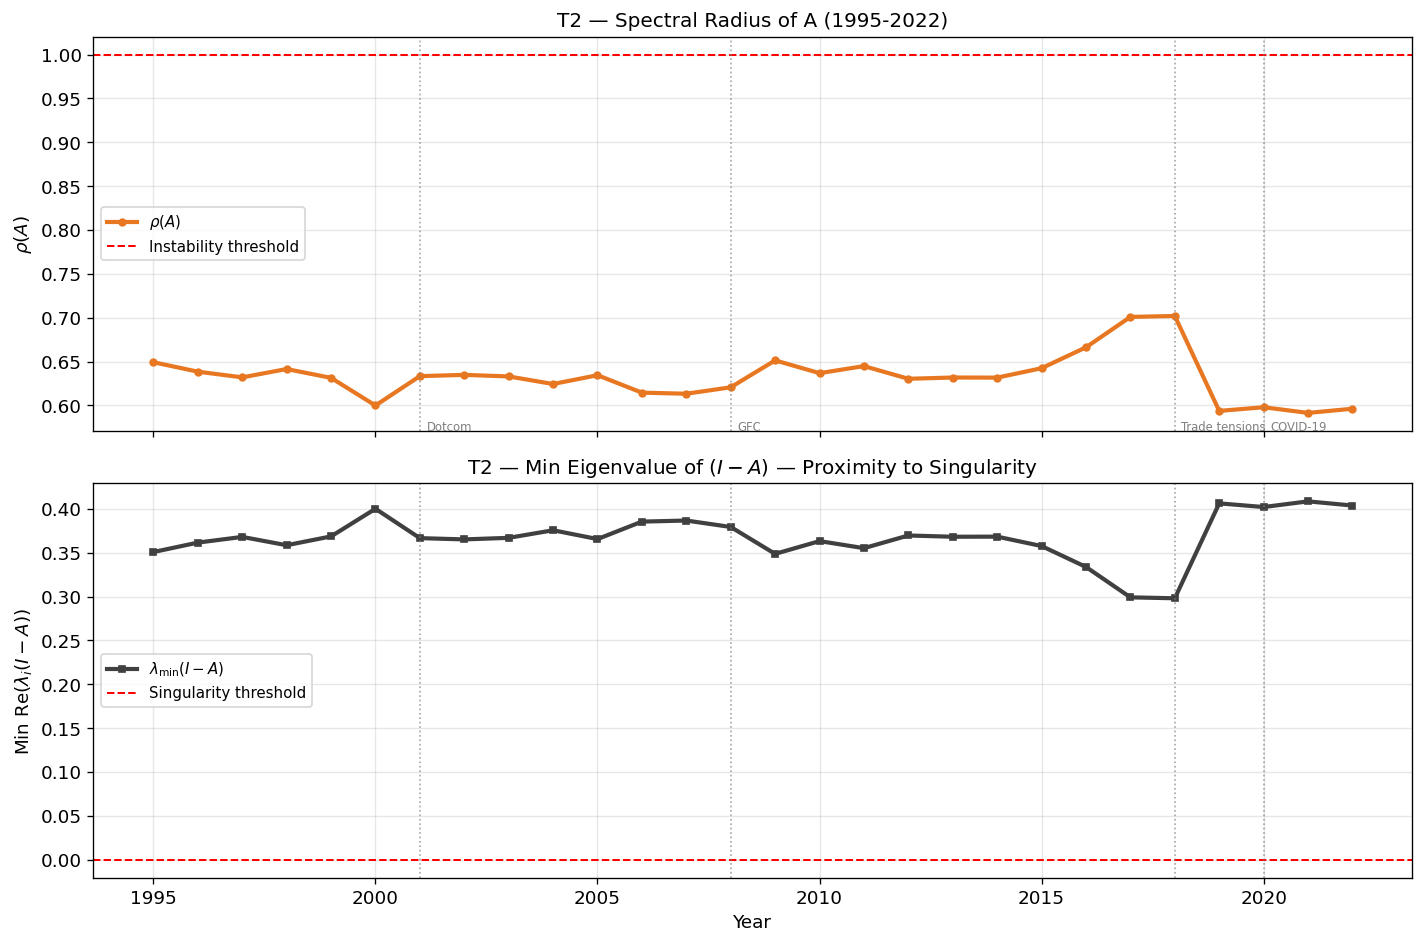

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1 = axes[0]
ax1.plot(df_T2.index, df_T2["rho_A"], color="#E87722", lw=2.5, marker="o", ms=4, label=r"$\rho(A)$")
ax1.axhline(1.0, color="red", ls="--", lw=1.2, label="Instability threshold")
for yr, lbl in shocks.items():
    ax1.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax1.text(yr+0.15, ax1.get_ylim()[0], lbl, fontsize=7, color="grey")
ax1.set_ylabel(r"$\rho(A)$", fontsize=11)
ax1.set_title("T2 — Spectral Radius of A (1995-2022)", fontsize=12)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(df_T2.index, df_T2["min_eval_IA"], color="#404040", lw=2.5, marker="s", ms=4,
         label=r"$\lambda_{\min}(I-A)$")
ax2.axhline(0.0, color="red", ls="--", lw=1.2, label="Singularity threshold")
for yr in shocks:
    ax2.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
ax2.set_ylabel(r"Min Re$(\lambda_i(I-A))$", fontsize=11)
ax2.set_xlabel("Year", fontsize=11)
ax2.set_title(r"T2 — Min Eigenvalue of $(I-A)$ — Proximity to Singularity", fontsize=12)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "T2_spectral_evolution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Verificación numérica: 1 - rho(A) debe coincidir con el autovalor mínimo de (I-A)
print("Verificación consistencia T2:")
print(f"{'Year':<6} {'rho_A':<8} {'1-rho_A':<10} {'min_eval_IA':<12} {'diferencia'}")
for year in sorted(df_T2.index):
    rho    = df_T2.loc[year, "rho_A"]
    min_ev = df_T2.loc[year, "min_eval_IA"]
    diff   = abs((1 - rho) - min_ev)
    print(f"{year:<6} {rho:<8.4f} {1-rho:<10.4f} {min_ev:<12.4f} {diff:.4f}")

Verificación consistencia T2:
Year   rho_A    1-rho_A    min_eval_IA  diferencia
1995   0.6493   0.3507     0.3507       0.0000
1996   0.6385   0.3615     0.3615       0.0000
1997   0.6320   0.3680     0.3680       0.0000
1998   0.6415   0.3585     0.3585       0.0000
1999   0.6315   0.3685     0.3685       0.0000
2000   0.6000   0.4000     0.4000       0.0000
2001   0.6334   0.3666     0.3666       0.0000
2002   0.6349   0.3651     0.3651       0.0000
2003   0.6331   0.3669     0.3669       0.0000
2004   0.6245   0.3755     0.3755       0.0000
2005   0.6345   0.3655     0.3655       0.0000
2006   0.6146   0.3854     0.3854       0.0000
2007   0.6134   0.3866     0.3866       0.0000
2008   0.6207   0.3793     0.3793       0.0000
2009   0.6514   0.3486     0.3486       0.0000
2010   0.6368   0.3632     0.3632       0.0000
2011   0.6449   0.3551     0.3551       0.0000
2012   0.6304   0.3696     0.3696       0.0000
2013   0.6318   0.3682     0.3682       0.0000
2014   0.6317   0.3683    

## 4. Sensibilidad estocástica de ρ(A) — T4 (Metodología §4.5, Resultados §5.3)
Perturbamos A directamente con ruido gaussiano de media cero, escalado a 12 múltiplos de la desviación estándar empírica de los coeficientes, y medimos la tasa de inestabilidad resultante.

In [ ]:
# Media y desviación estándar elemento a elemento de A a lo largo de los 28 años
A_stack = np.stack([A_dict[y].values for y in sorted(A_dict)], axis=0)
A_mean  = A_stack.mean(axis=0)
A_std   = A_stack.std(axis=0)

print(f"A_mean shape: {A_mean.shape}")
print(f"A_mean max: {A_mean.max():.4f}")
print(f"A_std max:  {A_std.max():.4f}")
print(f"A_mean global: {A_mean.mean():.6f}")

col_sums_mean = A_mean.sum(axis=0)
print(f"\nMax col sum de A_mean: {col_sums_mean.max():.4f}")
print(f"Mean col sum de A_mean: {col_sums_mean.mean():.4f}")

In [ ]:
VARIANCE_SCALES = np.linspace(0.5, 4.0, 12).tolist()
N_SIM = 200

records_T4 = []

for scale in VARIANCE_SCALES:
    rhos      = []
    min_evals = []

    for sim in range(N_SIM):
        # A sintética: media + escala * std * ruido
        A_sim = A_mean + scale * A_std * np.random.randn(*A_mean.shape)

        # Garantizar no negatividad
        A_sim = np.clip(A_sim, 0, None)

        # Garantizar columnas <= 1 (condición Leontief)
        col_sums = A_sim.sum(axis=0)
        bad_cols = col_sums > 1.0
        if bad_cols.any():
            A_sim[:, bad_cols] = A_sim[:, bad_cols] / col_sums[bad_cols][np.newaxis, :]

        try:
            lam_dom = spla.eigs(A_sim, k=1, which="LM",
                                return_eigenvectors=False,
                                tol=1e-4, maxiter=500)
            rho = float(np.abs(lam_dom[0]))
            rhos.append(rho)
            min_evals.append(1 - rho)
        except Exception:
            rhos.append(np.nan)
            min_evals.append(np.nan)

    rhos      = np.array(rhos)
    valid_rho = rhos[~np.isnan(rhos)]
    valid_min = (1 - valid_rho)

    records_T4.append({
        "scale"        : scale,
        "mean_rho"     : np.mean(valid_rho),
        "std_rho"      : np.std(valid_rho),
        "mean_min_eval": np.mean(valid_min),
        "p5_min_eval"  : np.percentile(valid_min, 5),
        "p95_min_eval" : np.percentile(valid_min, 95),
        "pct_unstable" : (valid_rho >= 1.0).mean() * 100,
    })
    print(f"scale={scale:.2f}x | mean_rho={np.mean(valid_rho):.4f} "
          f"± {np.std(valid_rho):.4f} | "
          f"unstable={records_T4[-1]['pct_unstable']:.1f}%")

df_T4 = pd.DataFrame(records_T4).set_index("scale")
df_T4.to_csv(os.path.join(OUTPUT_DIR, "T4_montecarlo_A.csv"))
display(df_T4.round(4))

In [ ]:
# Comprobamos qué porcentaje de columnas necesita re-normalización en cada
# escala — relevante para saber a partir de qué escala los resultados dejan
# de ser totalmente fiables (Sara: "<5% de columnas" es la zona robusta)
for scale in VARIANCE_SCALES:
    pct_normalized_list = []
    for sim in range(20):
        A_sim = np.clip(A_mean + scale * A_std *
                        np.random.randn(*A_mean.shape), 0, None)
        col_sums = A_sim.sum(axis=0)
        bad_cols = col_sums > 1.0
        pct_normalized_list.append(bad_cols.mean() * 100)
    print(f"scale={scale:.2f}x | "
          f"% columnas normalizadas: {np.mean(pct_normalized_list):.2f}%")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel 1 — evolución de rho con intervalo de confianza
ax1 = axes[0]
ax1.plot(df_T4.index, df_T4["mean_rho"],
         color="purple", lw=2.5, marker="o", ms=5,
         label=r"Mean $\rho(A_{sim})$")
ax1.fill_between(df_T4.index,
                 df_T4["mean_rho"] - df_T4["std_rho"],
                 df_T4["mean_rho"] + df_T4["std_rho"],
                 alpha=0.2, color="purple", label=r"$\pm 1\sigma$ interval")
ax1.axhline(1.0, color="red", ls="--", lw=1.2,
            label="Instability threshold")
ax1.axhline(0.7020, color="orange", ls=":", lw=1.2,
            label="Historical max $\\rho(A)$ = 0.702 (2018)")

ax1.set_ylabel(r"$\rho(A_{sim})$", fontsize=11)
ax1.set_title("Spectral Radius of $A^{(t)}$ (1995-2022)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.55, 1.05)

# Panel 2 — distancia a singularidad
ax2 = axes[1]
ax2.plot(df_T4.index, df_T4["mean_min_eval"],
         color="steelblue", lw=2.5, marker="s", ms=5,
         label=r"Mean min $\lambda(I-A)$")
ax2.fill_between(df_T4.index,
                 df_T4["p5_min_eval"],
                 df_T4["p95_min_eval"],
                 alpha=0.2, color="steelblue", label="P5-P95 interval")
ax2.axhline(0.0, color="red", ls="--", lw=1.2,
            label="Singularity threshold")

ax2.set_ylabel(r"Min $\lambda(I-A)$", fontsize=11)
ax2.set_xlabel(r"Variance scale ($\times$ empirical $\sigma_{a_{ij}}$)", fontsize=11)
ax2.set_title("Minimum Eigenvalue of $(I-A^{(t)})$ (1995-2022)", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "T4_montecarlo_results.png"), dpi=150, bbox_inches="tight")
plt.show()

### Gráfico final — 4 escalas representativas (citado en el TFM)

In [ ]:
SCALES_PLOT = [0.50, 1.14, 2.09, 4.00]
N_SIM = 200

all_rhos = {}  # guarda los 200 valores por escala

for scale in SCALES_PLOT:
    rhos = []
    for sim in range(N_SIM):
        A_sim = np.clip(
            A_mean + scale * A_std * np.random.randn(*A_mean.shape),
            0, None
        )
        col_sums = A_sim.sum(axis=0)
        bad_cols = col_sums > 1.0
        if bad_cols.any():
            A_sim[:, bad_cols] = A_sim[:, bad_cols] / col_sums[bad_cols][np.newaxis, :]

        try:
            lam = spla.eigs(A_sim, k=1, which="LM",
                            return_eigenvectors=False,
                            tol=1e-4, maxiter=500)
            rhos.append(float(np.abs(lam[0])))
        except Exception:
            rhos.append(np.nan)

    all_rhos[scale] = np.array(rhos)
    valid = np.array(rhos)[~np.isnan(rhos)]
    print(f"scale={scale:.2f}x | mean={valid.mean():.4f} ± {valid.std():.4f}")

print("Done.")

In [ ]:
# Gráfico final: nube de puntos de rho(A_sim) para las 4 escalas representativas
colors = ["steelblue", "seagreen", "darkorange", "crimson"]
labels = [f"scale={s}x" for s in SCALES_PLOT]

fig, ax = plt.subplots(figsize=(10, 5))

for idx, (scale, color) in enumerate(zip(SCALES_PLOT, colors)):
    vals = all_rhos[scale]
    vals = vals[~np.isnan(vals)]

    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), scale) + jitter,
               vals,
               color=color, alpha=0.3, s=15, label=labels[idx])

    ax.hlines(vals.mean(), scale - 0.12, scale + 0.12,
              color=color, lw=2.5, zorder=5)

ax.axhline(1.0, color="red", ls="--", lw=1.2, label="Instability threshold")
ax.axhline(0.7020, color="grey", ls=":", lw=1.2,
           label="Historical max ρ(A) = 0.702 (2018)")
ax.set_xlabel(r"Variance scale ($\times$ empirical $\sigma_{a_{ij}}$)", fontsize=11)
ax.set_ylabel(r"$\rho(A_{sim})$", fontsize=11)
ax.set_title(r"T4 — Distribution of $\rho(A_{sim})$ Across 200 Simulations "
             r"(< 5\% column normalization for scale ≤ 1.14x)", fontsize=11)
ax.set_xticks(SCALES_PLOT)
ax.set_xticklabels([f"{s}x" for s in SCALES_PLOT])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "T4_scatter_rho.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Mismo gráfico para min lambda(I-A) — vista complementaria de distancia a singularidad
fig, ax = plt.subplots(figsize=(10, 5))

for idx, (scale, color) in enumerate(zip(SCALES_PLOT, colors)):
    vals = 1 - all_rhos[scale]
    vals = vals[~np.isnan(vals)]

    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), scale) + jitter,
               vals,
               color=color, alpha=0.3, s=15, label=f"scale={scale}x")

    ax.hlines(vals.mean(), scale - 0.12, scale + 0.12,
              color=color, lw=2.5, zorder=5)

ax.axhline(0.0, color="red", ls="--", lw=1.2, label="Singularity threshold")
ax.set_xlabel(r"Variance scale ($\times$ empirical $\sigma_{a_{ij}}$)", fontsize=11)
ax.set_ylabel(r"Min $\lambda(I-A)$", fontsize=11)
ax.set_title(r"T4 — Distribution of Min $\lambda(I-A)$ Across 200 Simulations", fontsize=12)
ax.set_xticks(SCALES_PLOT)
ax.set_xticklabels([f"{s}x" for s in SCALES_PLOT])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "T4_scatter_eigenvalue.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Descomposición doméstico/internacional y país dominante — T3 (Metodología §4.8, Resultados §5.4)
Separamos $A = A_{dom} + A_{int}$ (bloques diagonales 50×50 por país vs. flujos entre países), y comparamos $\rho(A)$, $\rho(A_{dom})$ y $\rho(A_{int})$.

**Resultado clave**: $\rho(A) \approx \rho(A_{dom})$ con diferencia <0.005 en todos los años — el radio espectral global está determinado casi enteramente por el bloque doméstico más extremo, no por el comercio internacional.

In [ ]:
def separar_domestico_internacional(A_df, countries):
    """Separa A en su componente doméstica (bloques por país) e internacional."""
    A_vals = A_df.values.copy()
    A_dom = np.zeros_like(A_vals)
    A_int = A_vals.copy()

    for country in countries:
        mask = A_df.index.str.startswith(f"{country}_")
        idx = np.where(mask)[0]
        if len(idx) > 0:
            block = A_vals[np.ix_(idx, idx)]
            A_dom[np.ix_(idx, idx)] = block
            A_int[np.ix_(idx, idx)] = 0

    return A_dom, A_int


### Agregación a nivel país (83×83), comparación con la matriz completa
Necesaria para $\tilde{A}^{(t)}$ (robustez por agregación, Resultados §5.13). Se agrega sobre **Z** (flujos absolutos), no sobre A, para evitar la doble normalización.

In [ ]:
# Agregación correcta a nivel país: suma de Z (flujos absolutos), no de A
# (versión definitiva — la primera versión sumaba coeficientes ya normalizados,
# lo que daba un rho_agg artificialmente bajo; Sara lo detectó y se corrigió)
def aggregate_by_country_CORRECTO(Z, x, countries, sectors):
    """Agrega correctamente: suma Z (flujos absolutos) y divide por output país destino."""
    n, n_s = len(countries), len(sectors)
    Zv = Z.values
    Z_agg = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            Z_agg[i, j] = Zv[i*n_s:(i+1)*n_s,
                             j*n_s:(j+1)*n_s].sum()

    x_vals = x.values
    x_country = np.array([x_vals[j*n_s:(j+1)*n_s].sum()
                          for j in range(n)])
    x_safe = np.where(x_country > 0, x_country, np.nan)

    A_agg = Z_agg / x_safe[np.newaxis, :]
    A_agg = np.nan_to_num(A_agg, nan=0.0)
    return A_agg

A_agg_dict_corregido = {}
records_T3_corregido = []

for year in A_dict.keys():
    print(f"  {year}...", end=" ")
    rho_full = df_T2.loc[year, "rho_A"]

    A_agg_corr = aggregate_by_country_CORRECTO(Z_dict[year], X_dict[year], COUNTRIES, SECTORS)
    A_agg_dict_corregido[year] = A_agg_corr.copy()

    rho_agg_corr = float(np.max(np.abs(np.linalg.eigvals(A_agg_corr))))

    records_T3_corregido.append({
        "year": year,
        "rho_full": rho_full,
        "rho_agg_corregido": rho_agg_corr,
    })
    print(f"rho_full={rho_full:.4f} | rho_agg_corregido={rho_agg_corr:.4f}")

df_T3_corregido = pd.DataFrame(records_T3_corregido).set_index("year")
print("\nDone.")

In [ ]:
# Recalcular dom/int con A_agg corregida (usando Z, no A)
resultados_dom_int_corregido = {}

for year in A_dict.keys():
    print(f"  {year}...", end=" ")

    countries_list = list(set([c.split("_")[0] for c in A_dict[year].columns]))
    A_dom, A_int = separar_domestico_internacional(A_dict[year], countries_list)

    lam_dom = np.abs(spla.eigs(A_dom, k=1, which="LM", return_eigenvectors=False)[0])
    lam_int = np.abs(spla.eigs(A_int, k=1, which="LM", return_eigenvectors=False)[0])
    lam_full = df_T2.loc[year, "rho_A"]

    resultados_dom_int_corregido[year] = {
        "lam_full": lam_full,
        "lam_dom" : lam_dom,
        "lam_int" : lam_int,
    }
    print(f"full={lam_full:.4f} | dom={lam_dom:.4f} | int={lam_int:.4f}")

print("\nDone.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax1 = axes[0]
years_plot = sorted(df_T3_corregido.index)
ax1.plot(years_plot, df_T3_corregido["rho_full"],
         color="#E87722", lw=2.5, marker="o", ms=4,
         label=r"$\rho(A)$ — full 4,250-node")
ax1.plot(years_plot, df_T3_corregido["rho_agg_corregido"],
         color="#2C3E50", lw=1.8, marker="s", ms=4, ls="--",
         label=r"$\rho(\tilde{A})$ — 83-country aggregate")
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel(r"$\rho$", fontsize=11)
ax1.set_title("Full vs. Country-Aggregated Spectral Radius", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
years_plot2 = sorted(resultados_dom_int_corregido.keys())
full_vals = [resultados_dom_int_corregido[y]["lam_full"] for y in years_plot2]
dom_vals  = [resultados_dom_int_corregido[y]["lam_dom"]  for y in years_plot2]
int_vals  = [resultados_dom_int_corregido[y]["lam_int"]  for y in years_plot2]

ax2.plot(years_plot2, full_vals, color="#E87722", lw=3,
         label=r"$\rho(A)$")
ax2.plot(years_plot2, dom_vals, color="#2C3E50", lw=1.8,
         ls="--", marker="s", ms=5, markevery=2,
         label=r"$\rho(A_{\mathrm{dom}})$")
ax2.plot(years_plot2, int_vals, color="#95A5A6", lw=1.8,
         ls=":", marker="^", ms=5, markevery=2,
         label=r"$\rho(A_{\mathrm{int}})$")
ax2.set_xlabel("Year", fontsize=11)
ax2.set_ylabel(r"$\rho$", fontsize=11)
ax2.set_title("Domestic vs. International Spectral Radius", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Decomposition of the Global Spectral Radius, 1995--2022",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "T3_aggregation_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Figura separada
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(years_plot2, full_vals, color="#E87722", lw=3,
        label=r"$\rho(A)$")
ax.plot(years_plot2, dom_vals, color="#2C3E50", lw=1.8,
        ls="--", marker="s", ms=5, markevery=2,
        label=r"$\rho(A_{\mathrm{dom}})$")
ax.plot(years_plot2, int_vals, color="#95A5A6", lw=1.8,
        ls=":", marker="^", ms=5, markevery=2,
        label=r"$\rho(A_{\mathrm{int}})$")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"$\rho$", fontsize=11)
ax.set_title("Domestic vs. International Spectral Radius, 1995--2022",
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rho_domestic_vs_international.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
years_plot = sorted(df_T3_corregido.index)
full_vals = df_T3_corregido["rho_full"].tolist()
agg_vals = df_T3_corregido["rho_agg_corregido"].tolist()
gap_vals = [f - a for f, a in zip(full_vals, agg_vals)]

print(f"{'Year':<6} {'rho_full':<10} {'rho_agg':<10} {'gap'}")
print("-" * 40)
for y, f, a, g in zip(years_plot, full_vals, agg_vals, gap_vals):
    print(f"{y:<6} {f:<10.4f} {a:<10.4f} {g:.4f}")

print(f"\nMáximo rho_agg: {max(agg_vals):.4f} en {years_plot[agg_vals.index(max(agg_vals))]}")
print(f"Mínimo gap: {min(gap_vals):.4f} en {years_plot[gap_vals.index(min(gap_vals))]}")
print(f"Máximo gap: {max(gap_vals):.4f} en {years_plot[gap_vals.index(max(gap_vals))]}")
print(f"\n¿Invierte tendencia? rho_agg en 2016-2018:")
for y in [2015, 2016, 2017, 2018]:
    idx = years_plot.index(y)
    print(f"  {y}: rho_full={full_vals[idx]:.4f} | rho_agg={agg_vals[idx]:.4f}")

### Ranking de bloques domésticos por λ1 y país dominante por año
Calculamos el autovalor dominante de cada uno de los 83 bloques domésticos (50×50) y vemos qué país domina cada año. Este es el resultado que sustenta la narrativa "Malta → São Tomé → Camboya → Turquía → Malta → fragmentación" del TFM, y alimenta el Apéndice C.

In [ ]:
# Construir el dataframe completo de todos los autovalores de todos los bloques
# domésticos, todos los años (base para el ranking del país dominante)
records_T3_all_eigs = []

for year, A in A_dict.items():
    print(f"  {year}...", end=" ")
    Av = A.values

    idx = A.index.tolist()
    paises = list(dict.fromkeys(s.split("_")[0] for s in idx))
    n_s = sum(1 for s in idx if s.startswith(paises[0] + "_"))

    for i, country in enumerate(paises):
        block = Av[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s]
        evals = np.linalg.eigvals(block)

        for k, ev in enumerate(evals):
            records_T3_all_eigs.append({
                "year"     : year,
                "country"  : country,
                "eval_idx" : k,
                "eval_real": float(np.real(ev)),
                "eval_imag": float(np.imag(ev)),
                "eval_abs" : float(np.abs(ev)),
            })

    print("ok")

df_T3_all_eigs = pd.DataFrame(records_T3_all_eigs)
df_T3_all_eigs.to_csv(os.path.join(OUTPUT_DIR, "T3_all_eigenvalues.csv"), index=False)
display(df_T3_all_eigs.groupby("country")["eval_abs"].max().sort_values(ascending=False).head(10))

In [ ]:
# Ranking completo de lambda1 por bloque, top 5, para todos los años
print(f"{'Year':<6} {'#1':<20} {'#2':<20} {'#3':<20} {'#4':<20} {'#5'}")
print("-" * 105)

for year in years_sorted:
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
    A_dom, _ = separar_domestico_internacional(A_dict[year], countries_list)
    n_s = 50

    lam1_bloques = []
    for i, country in enumerate(countries_list):
        block = A_dom[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s].copy()
        if np.max(np.abs(block)) < 1e-10:
            continue
        lam1 = np.max(np.abs(np.linalg.eigvals(block)))
        lam1_bloques.append((country, lam1))

    top5 = sorted(lam1_bloques, key=lambda x: -x[1])[:5]
    top5_str = "  ".join([f"{p}({l:.4f})" for p, l in top5])
    print(f"{year:<6} {top5_str}")

print("\nDone.")

### Verificación — Apéndice D: λ2(A) ≈ λ1(segundo bloque más grande)

In [ ]:
# Verificación: ¿lambda2(A) ≈ lambda1(segundo bloque más grande)?
# Resultado del TFM: confirmado en 26 de 28 años, diferencia <0.005
print(f"{'Year':<6} {'λ1(A)':<10} {'λ2(A)':<10} {'País_1':<8} {'λ1_bloque1':<12} {'País_2':<8} {'λ1_bloque2':<12} {'λ2≈λ1_b2?'}")
print("-" * 85)

for year in years_sorted:
    A_vals = A_dict[year].values
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
    A_dom, _ = separar_domestico_internacional(A_dict[year], countries_list)
    n_s = 50

    lams_A = spla.eigs(A_vals, k=2, which="LM", return_eigenvectors=False)
    lams_A = sorted(np.abs(lams_A), reverse=True)
    lam1_A = lams_A[0]
    lam2_A = lams_A[1]

    lam1_bloques = []
    for i, country in enumerate(countries_list):
        block = A_dom[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s].copy()
        if np.max(np.abs(block)) < 1e-10:
            continue
        lam1 = np.max(np.abs(np.linalg.eigvals(block)))
        lam1_bloques.append((country, lam1))

    top2 = sorted(lam1_bloques, key=lambda x: -x[1])[:2]
    pais1, lam1_b1 = top2[0]
    pais2, lam1_b2 = top2[1]

    diff = abs(lam2_A - lam1_b2)
    match = "✅" if diff < 0.005 else f"diff={diff:.4f}"

    print(f"{year:<6} {lam1_A:<10.4f} {lam2_A:<10.4f} {pais1:<8} {lam1_b1:<12.4f} {pais2:<8} {lam1_b2:<12.4f} {match}")

print("\nDone.")

## 5b. Perturbación de primer orden: Ψ_c y δv_c (Metodología §4.8, Resultados §5.5)
Como $A_{int}$ tiene diagonal cero por construcción, la corrección de primer orden al autovalor dominante de cada bloque doméstico es exactamente cero. Lo que sí es medible: la magnitud de la perturbación entrante $\Psi_c$ y cómo redistribuye peso el autovector $\delta v_c$.

*Nota de reorganización: esta sección estaba dispersa y sin encabezados en el notebook original (bloque "NEW Adom"), con varios intentos duplicados de la misma cuenta. Aquí dejo solo la versión final/autocontenida de cada pieza — revisa los números contra el TFM antes de subir a GitHub, porque no he podido re-ejecutar el notebook (no tengo los CSV del ICIO).*

### Construcción de A_dom y A_int por año (necesaria para reutilizar bloques de años sueltos)

In [ ]:
def construir_A_dom(year):
    Z = Z_dict[year]
    x = X_dict[year]
    etiquetas = list(A_dict[year].index)
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
    n = len(etiquetas)
    
    A_dom = np.zeros((n, n))
    
    for country in countries_list:
        mask = [j for j, e in enumerate(etiquetas) if e.startswith(country + "_")]
        if len(mask) == 0:
            continue
        
        Z_block = Z.values[np.ix_(mask, mask)]
        x_block = x.values[mask]
        x_safe = np.where(x_block > 0, x_block, np.nan)
        A_block = np.nan_to_num(Z_block / x_safe[np.newaxis, :], nan=0.0)
        
        for ii, ri in enumerate(mask):
            for jj, ci in enumerate(mask):
                A_dom[ri, ci] = A_block[ii, jj]
    
    return A_dom

# Construir para todos los años
A_dom_dict = {}
for year in years_sorted:
    A_dom_dict[year] = construir_A_dom(year)
    print(f"✓ {year}")

In [ ]:
A_int_dict = {}
for year in years_sorted:
    A_int_dict[year] = A_dict[year].values - A_dom_dict[year]

### Validación del régimen perturbativo: ángulo entre v1(A_dom) y v1(A)

In [ ]:
# Validación régimen perturbativo: ángulo entre v1(A_dom) y v1(A)
print(f"{'Year':<6} {'Dom country':<12} {'Ángulo (°)':<12} {'||Δv1||':<10} {'Régimen'}")
print("-" * 55)

for year in years_sorted:
    etiquetas = list(A_dict[year].index)
    A_dom = A_dom_dict[year]
    A_vals = A_dict[year].values
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))

    # Autovector dominante de A_dom
    lam_dom, vec_dom = spla.eigs(A_dom, k=1, which="LM", return_eigenvectors=True)
    v_dom = np.real(vec_dom[:, 0])
    v_dom = v_dom / np.linalg.norm(v_dom)
    if np.sum(v_dom) < 0:
        v_dom = -v_dom

    # Autovector dominante de A completa
    lam_A, vec_A = spla.eigs(A_vals, k=1, which="LM", return_eigenvectors=True)
    v_A = np.real(vec_A[:, 0])
    v_A = v_A / np.linalg.norm(v_A)
    if np.sum(v_A) < 0:
        v_A = -v_A

    # País dominante
    bloques_year = {}
    for country in countries_list:
        mask = [j for j, e in enumerate(etiquetas) if e.startswith(country + "_")]
        if len(mask) == 0:
            continue
        block = A_dom[np.ix_(mask, mask)]
        if np.max(np.abs(block)) < 1e-10:
            continue
        lam1 = np.max(np.abs(np.linalg.eigvals(block)))
        bloques_year[country] = lam1
    dom = max(bloques_year, key=bloques_year.get)

    # Ángulo y norma de la diferencia
    coseno = np.dot(v_dom, v_A)
    angulo = np.degrees(np.arccos(np.clip(abs(coseno), -1, 1)))
    delta_v = np.linalg.norm(v_A - v_dom)

    regimen = "✓ perturbativo" if angulo < 5 else "⚠ borderline" if angulo < 15 else "✗ no perturbativo"

    print(f"{year:<6} {dom:<12} {angulo:<12.4f} {delta_v:<10.4f} {regimen}")

### Gaps espectrales entre bloques-país y pares casi-degenerados
Pares con gap $|\lambda_c-\lambda_{c'}|$ pequeño **y** autovectores dominantes similares (Bélgica–Grecia y Reino Unido–EEUU en 1995, Reino Unido–Portugal en 2018, España–Italia en 2022).

In [ ]:
import pandas as pd

for year in [1995, 2018, 2022]:
    etiquetas = list(A_dict[year].index)
    A_dom = A_dom_dict[year]
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))

    # Reconstruir bloques para ESTE año
    bloques = {}
    for country in countries_list:
        mask = [j for j, e in enumerate(etiquetas) if e.startswith(country + "_")]
        if len(mask) == 0:
            continue
        block = A_dom[np.ix_(mask, mask)]
        if np.max(np.abs(block)) < 1e-10:
            continue
        evals, evecs = np.linalg.eig(block)
        idx_dom = np.argmax(np.abs(evals))
        lam1 = np.abs(evals[idx_dom])
        v = np.real(evecs[:, idx_dom])
        v = v / np.linalg.norm(v)
        if np.sum(v) < 0:
            v = -v
        bloques[country] = {"lam1": lam1, "v": v, "mask": mask}

    countries = list(bloques.keys())

    # Pares quasi-degenerados reales
    pares_reales = []
    for i, a in enumerate(countries):
        for j, b in enumerate(countries):
            if i >= j:
                continue
            gap = abs(bloques[a]["lam1"] - bloques[b]["lam1"])
            if gap > 0.01:
                continue
            sim = abs(np.dot(bloques[a]["v"], bloques[b]["v"]))
            score = gap + (1 - sim)
            pares_reales.append((a, b, gap, sim, score))

    pares_sorted = sorted(pares_reales, key=lambda x: x[4])[:5]
    print(f"\n{year} — Pares quasi-degenerados REALES:")
    print(f"{'A':<6} {'B':<6} {'gap λ1':<10} {'|<va,vb>|':<12} {'score'}")
    print("-" * 45)
    for a, b, gap, sim, score in pares_sorted:
        print(f"{a:<6} {b:<6} {gap:<10.4f} {sim:<12.4f} {score:.4f}")

### Teoría de perturbaciones formal: δλ_k y δv_k (ecuaciones 7–8 de la memoria)

In [ ]:
# Teoría de perturbaciones formal: δλ_k y δv_k para cada país
# Requiere autovectores izquierdos u_k además de los derechos v_k

print(f"{'Year':<6} {'Country':<8} {'λ1_dom':<10} {'δλ_k':<12} {'δλ_k %':<10} {'Top país que más perturba δv_k'}")
print("-" * 75)

for year in [1995, 2018, 2022]:
    etiquetas = list(A_dict[year].index)
    A_dom = A_dom_dict[year]
    A_int = A_int_dict[year]
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))

    # PASO 1: autovectores derechos E IZQUIERDOS de cada bloque
    bloques = {}
    for country in countries_list:
        mask = [j for j, e in enumerate(etiquetas) if e.startswith(country + "_")]
        if len(mask) == 0:
            continue
        block = A_dom[np.ix_(mask, mask)]
        if np.max(np.abs(block)) < 1e-10:
            continue

        # Autovector derecho v_k
        evals, evecs_r = np.linalg.eig(block)
        idx_dom = np.argmax(np.abs(evals))
        lam1 = np.abs(evals[idx_dom])
        v = np.real(evecs_r[:, idx_dom])
        v = v / np.linalg.norm(v)
        if np.sum(v) < 0:
            v = -v

        # Autovector izquierdo u_k = autovector derecho de A^T
        _, evecs_l = np.linalg.eig(block.T)
        u = np.real(evecs_l[:, idx_dom])
        u = u / np.linalg.norm(u)
        if np.sum(u) < 0:
            u = -u

        # Biortogonalizar: escalar u para que u^T v = 1
        uv = np.dot(u, v)
        if abs(uv) > 1e-10:
            u = u / uv

        bloques[country] = {
            "lam1": lam1, "v": v, "u": u, "mask": mask
        }

    # PASO 2: δλ_k = u_k^T B v_k para cada país k
    # donde B = A_int (la perturbación)
    print(f"\n=== {year} ===")
    resultados_pert = {}

    for country_k, info_k in bloques.items():
        lam1_k = info_k["lam1"]
        v_k = info_k["v"]
        u_k = info_k["u"]
        mask_k = info_k["mask"]

        # δλ_k = u_k^T * (A_int * v_k_extendido) restringido a filas de k
        # = u_k^T * (suma sobre c'≠k de A_int[k,c'] * v_c' proyectado)
        # Simplificado: u_k^T * A_int[filas_k, :] * v_k_extendido_con_ceros
        # Como v_k_extendido tiene masa solo en mask_k, A_int[filas_k, mask_k] = 0
        # (porque A_int tiene ceros en los bloques diagonales)
        # Entonces: δλ_k = sum_{c'≠k} u_k^T * A_int[mask_k, mask_c'] * v_c'

        delta_lam = 0.0
        contrib_por_pais = {}

        for country_j, info_j in bloques.items():
            if country_j == country_k:
                continue
            mask_j = info_j["mask"]
            v_j = info_j["v"]

            # Bloque de A_int: filas de k, columnas de j
            B_kj = A_int[np.ix_(mask_k, mask_j)]

            # Contribución al δλ_k
            contrib = np.dot(u_k, B_kj @ v_j)
            delta_lam += contrib
            contrib_por_pais[country_j] = contrib

        delta_lam_pct = (delta_lam / lam1_k) * 100 if lam1_k > 1e-10 else 0

        # Top país que más contribuye a δλ_k
        top_pais = max(contrib_por_pais, key=lambda x: abs(contrib_por_pais[x]))
        top_contrib = contrib_por_pais[top_pais]

        resultados_pert[country_k] = {
            "lam1": lam1_k,
            "delta_lam": delta_lam,
            "delta_lam_pct": delta_lam_pct,
            "contrib_por_pais": contrib_por_pais,
            "top_pais": top_pais,
            "top_contrib": top_contrib
        }

    # Mostrar top 10 países más perturbados en δλ_k
    top10 = sorted(resultados_pert.items(),
                   key=lambda x: abs(x[1]["delta_lam_pct"]), reverse=True)[:10]

    print(f"{'Country':<8} {'λ1_dom':<10} {'δλ_k':<12} {'δλ_k %':<10} {'Top perturbador':<10} {'contrib'}")
    print("-" * 65)
    for country, res in top10:
        print(f"{country:<8} {res['lam1']:<10.4f} {res['delta_lam']:<12.6f} "
              f"{res['delta_lam_pct']:<10.2f}% {res['top_pais']:<10} {res['top_contrib']:.6f}")

    # PASO 3: δv_k para el país dominante — descomposición por país origen
    dom = max(bloques, key=lambda c: bloques[c]["lam1"])
    info_dom = bloques[dom]
    lam1_dom = info_dom["lam1"]
    v_dom = info_dom["v"]
    u_dom = info_dom["u"]
    mask_dom = info_dom["mask"]

    print(f"\nδv_{dom} (país dominante) — contribución por país de origen:")
    print(f"{'País j':<8} {'gap λ':<10} {'|contrib δv|':<15} {'dirección'}")
    print("-" * 45)

    contribs_dv = []
    for country_j, info_j in bloques.items():
        if country_j == dom:
            continue
        lam1_j = info_j["lam1"]
        v_j = info_j["v"]
        u_j = info_j["u"]
        mask_j = info_j["mask"]

        gap = lam1_dom - lam1_j
        if abs(gap) < 1e-10:
            continue

        # B_jk = A_int[filas_j, columnas_dom]
        B_jk = A_int[np.ix_(mask_j, mask_dom)]

        # Coeficiente: u_j^T * B_jk * v_dom / gap
        coef = np.dot(u_j, B_jk @ v_dom) / gap
        contribs_dv.append((country_j, gap, abs(coef), coef))

    contribs_dv_sorted = sorted(contribs_dv, key=lambda x: -x[2])[:8]
    for pais, gap, mag, coef in contribs_dv_sorted:
        direccion = "+" if coef > 0 else "-"
        print(f"{pais:<8} {gap:<10.4f} {mag:<15.6f} {direccion}")

In [ ]:
# Evolución temporal de δλ_k para países seleccionados
paises_plot = ["MLT", "STP", "KHM", "TUR", "SVK", "AUT"]

resultados_serie = {p: [] for p in paises_plot}

for year in years_sorted:
    etiquetas = list(A_dict[year].index)
    A_dom = A_dom_dict[year]
    A_int = A_int_dict[year]
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))

    bloques = {}
    for country in countries_list:
        mask = [j for j, e in enumerate(etiquetas) if e.startswith(country + "_")]
        if len(mask) == 0:
            continue
        block = A_dom[np.ix_(mask, mask)]
        if np.max(np.abs(block)) < 1e-10:
            continue
        evals, evecs_r = np.linalg.eig(block)
        idx_dom = np.argmax(np.abs(evals))
        lam1 = np.abs(evals[idx_dom])
        v = np.real(evecs_r[:, idx_dom])
        v = v / np.linalg.norm(v)
        if np.sum(v) < 0:
            v = -v
        _, evecs_l = np.linalg.eig(block.T)
        u = np.real(evecs_l[:, idx_dom])
        u = u / np.linalg.norm(u)
        if np.sum(u) < 0:
            u = -u
        uv = np.dot(u, v)
        if abs(uv) > 1e-10:
            u = u / uv
        bloques[country] = {"lam1": lam1, "v": v, "u": u, "mask": mask}

    for country_k in paises_plot:
        if country_k not in bloques:
            resultados_serie[country_k].append(np.nan)
            continue

        info_k = bloques[country_k]
        lam1_k = info_k["lam1"]
        v_k = info_k["v"]
        u_k = info_k["u"]
        mask_k = info_k["mask"]

        delta_lam = 0.0
        for country_j, info_j in bloques.items():
            if country_j == country_k:
                continue
            mask_j = info_j["mask"]
            v_j = info_j["v"]
            B_kj = A_int[np.ix_(mask_k, mask_j)]
            delta_lam += np.dot(u_k, B_kj @ v_j)

        delta_lam_pct = (delta_lam / lam1_k) * 100
        resultados_serie[country_k].append(delta_lam_pct)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
for pais in paises_plot:
    ax.plot(years_sorted, resultados_serie[pais], marker="o", ms=4,
            lw=2, label=pais)

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("δλ_k / λ_k (%) — perturbación relativa", fontsize=11)
ax.set_title("Evolución temporal de la perturbación espectral internacional\n"
             "para los países dominantes en cada período", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "perturbacion_temporal_paises.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### Ψ_c = ‖Σ_{c'≠c} A_int[c,c'] · v_c'‖ — supply-side spectral pull

In [ ]:
# Ψ_c = ||sum_{c'≠c} A_int[c,c'] @ v_c'|| — sin u_c, bien definido
paises_grandes = ["USA", "DEU", "CN1", "RUS", "MLT"]

for year in [1995, 2018, 2022]:
    print(f"\n=== {year} ===")
    etiquetas = list(A_dict[year].index)
    A_dom = A_dom_dict[year]
    A_int = A_int_dict[year]
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))

    # Autovectores derechos de cada bloque
    bloques = {}
    for country in countries_list:
        mask = [j for j, e in enumerate(etiquetas) if e.startswith(country + "_")]
        if len(mask) == 0:
            continue
        block = A_dom[np.ix_(mask, mask)]
        if np.max(np.abs(block)) < 1e-10:
            continue
        evals, evecs_r = np.linalg.eig(block)
        idx = np.argmax(np.abs(evals))
        lam1 = np.abs(evals[idx])
        v = np.real(evecs_r[:, idx])
        v = v / np.linalg.norm(v)
        if np.sum(v) < 0:
            v = -v
        bloques[country] = {"lam1": lam1, "v": v, "mask": mask}

    # Norma de Frobenius de A_int para normalizar
    norm_Aint = np.linalg.norm(A_int, 'fro')

    print(f"{'Country':<8} {'λ1_dom':<10} {'Ψ_c (bruto)':<15} {'Ψ_c/||A_int||_F'}")
    print("-" * 50)

    for country_k in paises_grandes:
        if country_k not in bloques:
            print(f"{country_k:<8} NO DISPONIBLE")
            continue
        info_k = bloques[country_k]
        mask_k = info_k["mask"]
        lam1_k = info_k["lam1"]

        # Suma de A_int[c,c'] @ v_c' para todos c'≠c
        suma = np.zeros(len(mask_k))
        for country_j, info_j in bloques.items():
            if country_j == country_k:
                continue
            mask_j = info_j["mask"]
            v_j = info_j["v"]
            B_kj = A_int[np.ix_(mask_k, mask_j)]
            suma += B_kj @ v_j

        psi = np.linalg.norm(suma)
        print(f"{country_k:<8} {lam1_k:<10.4f} {psi:<15.6f} {psi/norm_Aint:.6f}")

In [ ]:
# Ψ_c para todos los años — serie completa
paises_plot = ["USA", "DEU", "CN1", "RUS", "MLT"]
colors_paises = {
    "USA": "#2980B9",
    "DEU": "#8E44AD", 
    "CN1": "#E74C3C",
    "RUS": "#E67E22",
    "MLT": "#27AE60"
}

resultados_psi = {p: [] for p in paises_plot}
years_sorted_list = sorted(years_sorted)

for year in years_sorted_list:
    etiquetas = list(A_dict[year].index)
    A_dom = A_dom_dict[year]
    A_int = A_int_dict[year]
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))

    # Autovectores derechos
    bloques = {}
    for country in countries_list:
        mask = [j for j, e in enumerate(etiquetas) if e.startswith(country + "_")]
        if len(mask) == 0:
            continue
        block = A_dom[np.ix_(mask, mask)]
        if np.max(np.abs(block)) < 1e-10:
            continue
        evals, evecs_r = np.linalg.eig(block)
        idx = np.argmax(np.abs(evals))
        v = np.real(evecs_r[:, idx])
        v = v / np.linalg.norm(v)
        if np.sum(v) < 0:
            v = -v
        bloques[country] = {"v": v, "mask": mask}

    norm_Aint = np.linalg.norm(A_int, 'fro')

    for country_k in paises_plot:
        if country_k not in bloques:
            resultados_psi[country_k].append(np.nan)
            continue
        mask_k = bloques[country_k]["mask"]
        suma = np.zeros(len(mask_k))
        for country_j, info_j in bloques.items():
            if country_j == country_k:
                continue
            mask_j = info_j["mask"]
            v_j = info_j["v"]
            B_kj = A_int[np.ix_(mask_k, mask_j)]
            suma += B_kj @ v_j
        psi = np.linalg.norm(suma) / norm_Aint
        resultados_psi[country_k].append(psi)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for pais in paises_plot:
    ax.plot(years_sorted_list, resultados_psi[pais],
            color=colors_paises[pais], lw=2.5 if pais != "MLT" else 1.5,
            marker="o", ms=4,
            ls="-" if pais != "MLT" else "--",
            label=pais)

# Marcar eventos clave
for yr, lbl in {2001: "dot-com", 2008: "GFC", 2020: "COVID"}.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(yr + 0.15, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.01,
            lbl, fontsize=7, color="grey", rotation=90, va="bottom")

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"$\tilde{\Psi}_c = \Psi_c / \|A^{(t)}_{\mathrm{int}}\|_F$",
              fontsize=11)
ax.set_title("International Spectral Exposure by Country, 1995--2022\n"
             r"$\tilde{\Psi}_c$: normalised perturbation reaching each economy's dominant mode",
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "psi_exposure_series.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Imprimir tabla también
print(f"\n{'Year':<6}", end="")
for p in paises_plot:
    print(f"{p:<10}", end="")
print()
print("-" * 56)
for i, year in enumerate(years_sorted_list):
    print(f"{year:<6}", end="")
    for p in paises_plot:
        print(f"{resultados_psi[p][i]:<10.4f}", end="")
    print()

### Gráfico final — citado en el TFM como psi_exposure_series.png

In [ ]:
fig, (ax_main, ax_mlt) = plt.subplots(1, 2, figsize=(14, 5),
                                        gridspec_kw={"width_ratios": [3, 1]})

paises_grandes = ["USA", "DEU", "CN1", "RUS"]
colors_paises = {
    "USA": "#2980B9", "DEU": "#8E44AD",
    "CN1": "#E74C3C", "RUS": "#E67E22", "MLT": "#27AE60"
}

for pais in paises_grandes:
    ax_main.plot(years_sorted_list, resultados_psi[pais],
                 color=colors_paises[pais], lw=2.5,
                 marker="o", ms=4, label=pais)

for yr, lbl in {2001: "dot-com", 2008: "GFC", 2020: "COVID"}.items():
    ax_main.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax_main.text(yr+0.15, 0.01, lbl, fontsize=7, color="grey",
                 rotation=90, va="bottom")

ax_main.set_xlabel("Year", fontsize=11)
ax_main.set_ylabel(r"$\tilde{\Psi}_c = \Psi_c / \|A^{(t)}_{\mathrm{int}}\|_F$", fontsize=11)
ax_main.set_title("International Spectral Exposure — Major Economies", fontsize=11)
ax_main.legend(fontsize=10)
ax_main.grid(True, alpha=0.3)

ax_mlt.plot(years_sorted_list, resultados_psi["MLT"],
            color=colors_paises["MLT"], lw=2, marker="o", ms=4)
for yr in [2001, 2008, 2020]:
    ax_mlt.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
ax_mlt.set_xlabel("Year", fontsize=11)
ax_mlt.set_ylabel(r"$\tilde{\Psi}_{\mathrm{MLT}}$", fontsize=11)
ax_mlt.set_title("MLT (own scale)", fontsize=11)
ax_mlt.grid(True, alpha=0.3)
ax_mlt.tick_params(axis='x', rotation=45)

plt.suptitle(r"$\tilde{\Psi}_c$: normalised international spectral exposure, 1995--2022",
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "psi_exposure_series.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 6. Realidad del espectro dominante — ruptura de universalidad RMT (Metodología §4.3, Resultados §5.4)
El primer autovalor complejo nunca aparece antes del rango 18 en ningún año — evidencia de que el espectro está dominado por la estructura casi-bloque-diagonal, no por comportamiento tipo matriz aleatoria (Girko).

In [ ]:
# Posición del primer autovalor complejo en A completa (top 100), todos los años
print(f"{'Year':<6} {'k primer complejo':<22} {'|λk|':<12} {'Im(λk)':<15} {'Re(λk)'}")
print("-" * 68)

for year in years_sorted:
    A_vals = A_dict[year].values

    lams = spla.eigs(A_vals, k=100, which="LM", return_eigenvectors=False)
    lams = sorted(lams, key=lambda x: -abs(x))

    primer_complejo = None
    for k, lam in enumerate(lams):
        if abs(lam.imag) > 1e-8:
            primer_complejo = (k+1, lam)
            break

    if primer_complejo:
        k, lam = primer_complejo
        print(f"{year:<6} {k:<22} {abs(lam):<12.6f} {lam.imag:<15.6f} {lam.real:.6f}")
    else:
        print(f"{year:<6} {'> 100 (todos reales)':<22}")

print("\nDone.")

In [ ]:
# Posición del primer complejo en el RANKING COMBINADO de todos los bloques
# domésticos (no en A completa) — verificado para todos los años
print(f"{'Year':<6} {'k_primer_cmplx_bloques':<25} {'|λ|':<10} {'Im':<12} {'País'}")
print("-" * 65)

for year in years_sorted:
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
    A_dom, _ = separar_domestico_internacional(A_dict[year], countries_list)
    n_s = 50

    todos_lams = []
    for i, country in enumerate(countries_list):
        block = A_dom[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s].copy()
        if np.max(np.abs(block)) < 1e-10:
            continue
        lams = np.linalg.eigvals(block)
        for lam in lams:
            todos_lams.append((country, lam))

    todos_lams = sorted(todos_lams, key=lambda x: -abs(x[1]))

    primer_cmplx_k = None
    for k, (country, lam) in enumerate(todos_lams):
        if abs(lam.imag) > 1e-8:
            primer_cmplx_k = k+1
            print(f"{year:<6} {primer_cmplx_k:<25} {abs(lam):<10.4f} {lam.imag:<12.4e} {country}")
            break

    if primer_cmplx_k is None:
        print(f"{year:<6} {'> 4150 (todos reales)':<25}")

print("\nDone.")

### Gráfico definitivo de 3 paneles (citado en el TFM, 2018)

In [ ]:
year = 2018
countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
A_dom, _ = separar_domestico_internacional(A_dict[year], countries_list)
n_s = 50

# Recoger todos los autovalores: lambda1 de cada bloque y el resto (bulk)
todos_lams = []
lam1_re, lam1_im = [], []
lams_bulk = []

for i, country in enumerate(countries_list):
    block = A_dom[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s].copy()
    if np.max(np.abs(block)) < 1e-10:
        continue
    lams = np.linalg.eigvals(block)
    lams_sorted = sorted(lams, key=lambda x: -abs(x))

    lam1_re.append(lams_sorted[0].real)
    lam1_im.append(lams_sorted[0].imag)

    for lam in lams_sorted[1:]:
        lams_bulk.append(lam)

re_bulk = np.array([l.real for l in lams_bulk])
im_bulk = np.array([l.imag for l in lams_bulk])

# sigma medio y radio de Girko
sigma_vals = []
for i, country in enumerate(countries_list):
    block = A_dom[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s].copy()
    if np.max(np.abs(block)) < 1e-10:
        continue
    sigma_vals.append(np.std(block))
sigma_mean = np.mean(sigma_vals)
r_girko = sigma_mean * np.sqrt(n_s)
theta = np.linspace(0, 2*np.pi, 200)

print(f"r_girko = {r_girko:.4f}")
print(f"N autovalores bulk: {len(lams_bulk)}")
print(f"N λ1: {len(lam1_re)}")
print(f"N total (bulk + λ1) = {len(lams_bulk) + len(lam1_re)} (= 83 × 50 = 4150)")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — plano complejo
ax1 = axes[0]
ax1.scatter(re_bulk, im_bulk, alpha=0.15, s=3, color="darkorange", zorder=1)
ax1.scatter(lam1_re, lam1_im, alpha=0.9, s=40, color="steelblue",
            zorder=5, label=r"$\lambda_1$ (Perron)")
ax1.plot(r_girko*np.cos(theta), r_girko*np.sin(theta),
         'r-', lw=2.5, label=f"Girko (r={r_girko:.3f})", zorder=6)
ax1.axhline(0, color="black", lw=1.2, alpha=0.8, zorder=4)
ax1.set_xlabel("Re(λ)", fontsize=11)
ax1.set_ylabel("Im(λ)", fontsize=11)
ax1.set_title("Complex plane", fontsize=11)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2 — histograma de Im(λ) vs predicción RMT
ax2 = axes[1]
ax2.hist(im_bulk, bins=80, color="darkorange", alpha=0.7, density=True,
         label="Empirical Im(λ)")
r = r_girko
x_rmt = np.linspace(-r, r, 200)
density_rmt = (2 / (np.pi * r**2)) * np.sqrt(np.maximum(r**2 - x_rmt**2, 0))
ax2.plot(x_rmt, density_rmt, 'r-', lw=2, label="RMT prediction (circular law)")
ax2.set_xlabel("Im(λ)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("Distribution of Im(λ)\nvs. RMT prediction", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3 — CDF de |Im(λ)|
ax3 = axes[2]
im_abs = np.sort(np.abs(im_bulk))
frac = np.arange(1, len(im_abs)+1) / len(im_abs)
ax3.plot(im_abs, frac, color="darkorange", lw=2, label="Empirical CDF")
y_vals = np.linspace(0, r, 200)
cdf_rmt = (2/np.pi) * np.arcsin(y_vals/r)
ax3.plot(y_vals, cdf_rmt, 'r-', lw=2, label="RMT prediction")
ax3.axvline(0.01, color="grey", ls=":", lw=1, alpha=0.7)
frac_real = np.mean(np.abs(im_bulk) < 0.01)
ax3.text(0.015, 0.3, f"{frac_real*100:.1f}% have\n|Im|<0.01", fontsize=9)
ax3.set_xlabel("|Im(λ)|", fontsize=11)
ax3.set_ylabel("Cumulative fraction", fontsize=11)
ax3.set_title("CDF of |Im(λ)|\nEmpirical vs. RMT", fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, r*1.2)

plt.suptitle("Breakdown of RMT Universality in Domestic I-O Blocks (2018)\n"
             "Eigenvalues concentrate on real axis vs. Girko circular law prediction",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "RMT_breakdown_blocks_2018.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"\n{frac_real*100:.1f}% de autovalores bulk tienen |Im|<0.01")

In [ ]:
SCALES_PLOT = [0.50, 1.14, 2.09, 4.00]
colors_scatter = ["steelblue", "seagreen", "darkorange", "crimson"]

fig, ax = plt.subplots(figsize=(10, 5))

for idx, (scale, color) in enumerate(zip(SCALES_PLOT, colors_scatter)):
    vals = all_rhos[scale]
    vals = vals[~np.isnan(vals)]

    # Violin plot — mucho más claro que scatter apelotado
    parts = ax.violinplot(vals, positions=[scale], widths=0.18,
                          showmeans=True, showmedians=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.45)
    parts['cmeans'].set_color(color)
    parts['cmeans'].set_linewidth(2.5)
    parts['cbars'].set_color(color)
    parts['cmins'].set_color(color)
    parts['cmaxes'].set_color(color)

    # Puntos individuales encima, pequeños y transparentes
    jitter = np.random.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter(np.full(len(vals), scale) + jitter,
               vals, color=color, alpha=0.2, s=6, zorder=2)

ax.axhline(1.0, color="red", ls="--", lw=1.5, label="Instability threshold")
ax.axhline(0.7020, color="grey", ls=":", lw=1.2,
           label="Historical max ρ(A) = 0.702 (2018)")

ax.set_xlabel(r"Variance scale ($\times$ empirical $\sigma_{a_{ij}}$)", fontsize=11)
ax.set_ylabel(r"$\rho(A_{\mathrm{sim}})$", fontsize=11)
ax.set_title("Distribution of $\\rho(A_{\\mathrm{sim}})$ Across 200 Simulations "
             "(< 5% column normalization for scale <= 1.14x)", fontsize=11)
ax.set_xticks(SCALES_PLOT)
ax.set_xticklabels([f"{s}x" for s in SCALES_PLOT])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.55, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "T4_scatter_rho.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# RMT BREAKDOWN — 3 figuras separadas
# ============================================================

# Panel 1 — Plano complejo
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(re_bulk, im_bulk, alpha=0.15, s=3, color="darkorange", zorder=1)
ax.scatter(lam1_re, lam1_im, alpha=0.9, s=40, color="steelblue",
           zorder=5, label=r"$\lambda_1$ (Perron)")
ax.plot(r_girko*np.cos(theta), r_girko*np.sin(theta),
        'r-', lw=2.5, label=f"Girko (r={r_girko:.3f})", zorder=6)
ax.axhline(0, color="black", lw=1.2, alpha=0.8, zorder=4)
ax.set_xlabel("Re(λ)", fontsize=12)
ax.set_ylabel("Im(λ)", fontsize=12)
ax.set_title("Eigenvalue Distribution in the Complex Plane\n"
             "Domestic blocks of $A^{(2018)}$ vs. Girko circular law", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "RMT_complex_plane.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ RMT_complex_plane.png")

# Panel 2 — Histograma Im(λ) vs RMT
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(im_bulk, bins=80, color="darkorange", alpha=0.7, density=True,
        label="Empirical Im(λ)")
r = r_girko
x_rmt = np.linspace(-r, r, 200)
density_rmt = (2 / (np.pi * r**2)) * np.sqrt(np.maximum(r**2 - x_rmt**2, 0))
ax.plot(x_rmt, density_rmt, 'r-', lw=2, label="RMT prediction (circular law)")
ax.set_xlabel("Im(λ)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Distribution of Im(λ) vs. RMT Prediction\n"
             "Domestic blocks of $A^{(2018)}$", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "RMT_histogram.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ RMT_histogram.png")

# Panel 3 — CDF de |Im(λ)|
fig, ax = plt.subplots(figsize=(8, 5))
im_abs = np.sort(np.abs(im_bulk))
frac = np.arange(1, len(im_abs)+1) / len(im_abs)
ax.plot(im_abs, frac, color="darkorange", lw=2, label="Empirical CDF")
y_vals = np.linspace(0, r, 200)
cdf_rmt = (2/np.pi) * np.arcsin(y_vals/r)
ax.plot(y_vals, cdf_rmt, 'r-', lw=2, label="RMT prediction")
ax.axvline(0.01, color="grey", ls=":", lw=1, alpha=0.7)
frac_real = np.mean(np.abs(im_bulk) < 0.01)
ax.text(0.015, 0.3, f"{frac_real*100:.1f}% have\n|Im|<0.01", fontsize=10)
ax.set_xlabel("|Im(λ)|", fontsize=12)
ax.set_ylabel("Cumulative fraction", fontsize=12)
ax.set_title("CDF of |Im(λ)|: Empirical vs. RMT Prediction\n"
             "Domestic blocks of $A^{(2018)}$", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, r*1.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "RMT_cdf.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ RMT_cdf.png")

In [ ]:
def tabla_top10_a_png(años, nombre_archivo, titulo):
    top_n = 10
    filas = [f"Top {i+1}" for i in range(top_n)]
    columnas = [str(y) for y in años]

    colores_pais = {
        "MLT": "#E87722", "STP": "#3498DB", "KHM": "#E74C3C",
        "TUR": "#2ECC71", "MAR": "#9B59B6", "BRN": "#F39C12",
        "SVK": "#1ABC9C", "JPN": "#34495E", "AUT": "#D35400",
        "ROW": "#7F8C8D", "USA": "#2980B9", "DEU": "#8E44AD",
    }

    data = []
    colors = []

    for rank in range(top_n):
        fila_texto = []
        fila_color = []
        for year in años:
            if year in tabla_nodos and rank < len(tabla_nodos[year]):
                nodo, peso = tabla_nodos[year][rank]
                pais = nodo.split("_")[0]
                sector = nodo.split("_")[1] if "_" in nodo else ""
                texto = f"{pais}\n{sector}\n({peso:.3f})"
                color = colores_pais.get(pais, "#ECF0F1")
            else:
                texto = ""
                color = "white"
            fila_texto.append(texto)
            fila_color.append(color)
        data.append(fila_texto)
        colors.append(fila_color)

    # Figura más grande para que el texto sea legible
    fig, ax = plt.subplots(figsize=(len(años) * 2.4, top_n * 1.4 + 2))
    ax.axis("off")

    tabla = ax.table(
        cellText=data,
        rowLabels=filas,
        colLabels=columnas,
        cellLoc="center",
        loc="center"
    )

    for (row, col), cell in tabla.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2C3E50")
            cell.set_text_props(color="white", fontsize=12, fontweight="bold")
            cell.set_height(0.10)
        elif col == -1:
            cell.set_facecolor("#BDC3C7")
            cell.set_text_props(fontsize=11, fontweight="bold")
            cell.set_width(0.08)
        else:
            color = colors[row-1][col]
            cell.set_facecolor(color)
            cell.set_text_props(
                fontsize=10,
                color="white" if color not in ["white", "#ECF0F1"] else "black"
            )
            cell.set_height(0.11)

    tabla.scale(1, 1.6)

    plt.suptitle(titulo, fontsize=13, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, nombre_archivo),
        dpi=200,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()
    print(f"✓ {nombre_archivo}")

# Generar las dos mitades
años_1 = list(range(1995, 2009))
tabla_top10_a_png(
    años_1,
    "appendix_top10_nodos_1995_2008.png",
    "Top-10 Nodes by Dominant Eigenvector Weight — 1995 to 2008"
)

años_2 = list(range(2009, 2022))
tabla_top10_a_png(
    años_2,
    "appendix_top10_nodos_2009_2022.png",
    "Top-10 Nodes by Dominant Eigenvector Weight — 2009 to 2022"
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))

years_plot2 = sorted(resultados_dom_int_corregido.keys())
dom_vals  = [resultados_dom_int_corregido[y]["lam_dom"]  for y in years_plot2]
int_vals  = [resultados_dom_int_corregido[y]["lam_int"]  for y in years_plot2]
full_vals = [resultados_dom_int_corregido[y]["lam_full"] for y in years_plot2]

# rho(A) — línea sólida gruesa, sin marcador
ax.plot(years_plot2, full_vals, color="#E87722", lw=3,
        label=r"$\rho(A)$ — full matrix")

# rho(A_dom) — línea discontinua con marcadores cuadrados
# así se ve aunque coincida con rho(A)
ax.plot(years_plot2, dom_vals, color="#2C3E50", lw=1.8,
        ls="--", marker="s", ms=5, markevery=2,
        label=r"$\rho(A_{\mathrm{dom}})$ — domestic blocks")

# rho(A_int) — línea punteada con marcadores triángulo
ax.plot(years_plot2, int_vals, color="#95A5A6", lw=1.8,
        ls=":", marker="^", ms=5, markevery=2,
        label=r"$\rho(A_{\mathrm{int}})$ — international linkages")

for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(yr + 0.15, ax.get_ylim()[0] + 0.01, lbl, fontsize=7, color="grey")

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"$\rho$", fontsize=11)
ax.set_title(r"Domestic vs. International Spectral Radius (1995--2022)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rho_domestic_vs_international.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 7. Shapiro–Wilk: normalidad de los coeficientes técnicos (Metodología §4.4, Resultados §5.13)
Test aplicado a una muestra de 10.000 pares de coeficientes, sobre su serie de 28 años, para justificar (o no) el supuesto de ruido gaussiano de la Sección 4.

In [ ]:
years_list = list(range(1995, 2022))

# Extraer todas las matrices a numpy ANTES del bucle (optimización clave:
# acceder a A_dict[year].values dentro del bucle es mucho más lento)
print("Extrayendo matrices numpy...")
A_matrices = np.stack([A_dict[year].values for year in years_list], axis=2)
# Shape: (4250, 4250, 28) — [i, j, t]
print(f"Shape: {A_matrices.shape}")

N = A_matrices.shape[0]

# Muestrear pares (i,j) aleatorios
np.random.seed(42)
n_muestra = 10000
pares_i = np.random.randint(0, N, n_muestra)
pares_j = np.random.randint(0, N, n_muestra)

n_rechaza = 0
n_total   = 0
p_valores = []
w_valores = []

print("Ejecutando Shapiro-Wilk...")
for k in range(n_muestra):
    i, j = pares_i[k], pares_j[k]
    serie = A_matrices[i, j, :]  # los 28 valores de a_ij — acceso directo numpy

    if np.sum(serie > 1e-10) < 3:
        continue

    stat, p = shapiro(serie)
    p_valores.append(p)
    w_valores.append(stat)
    n_total += 1
    if p < 0.05:
        n_rechaza += 1

print(f"\nResultados Shapiro-Wilk sobre {n_total} coeficientes a_ij:")
print(f"  Rechazan normalidad (p<0.05): {n_rechaza} ({n_rechaza/n_total*100:.1f}%)")
print(f"  No rechazan:                  {n_total-n_rechaza} ({(n_total-n_rechaza)/n_total*100:.1f}%)")
print(f"  p-valor medio: {np.mean(p_valores):.4f}")
print(f"  W medio:       {np.mean(w_valores):.4f}")

## 8. Pseudo-degeneración M(t) y localización IPR (Metodología §4.6–4.7, Resultados §5.6)
Calculamos los 10 autovalores dominantes de A por año y la distancia relativa a λ1, para construir el índice de pseudo-degeneración M(t) a los umbrales 1% y 5%.

In [ ]:
# PASO 1 — 10 autovalores más grandes por año
resultados_top10 = {}

for year, A in A_dict.items():
    print(f"  {year}...", end=" ")

    lam_top10 = spla.eigs(A_dict[year].values, k=10, which="LM",
                          return_eigenvectors=False)

    lam_sorted = sorted(lam_top10, key=lambda x: np.abs(x), reverse=True)

    magnitudes = [np.abs(l) for l in lam_sorted]

    lambda_1 = magnitudes[0]
    distancias = [(lambda_1 - m) / lambda_1 for m in magnitudes]

    resultados_top10[year] = {
        "magnitudes" : magnitudes,
        "distancias" : distancias,
        "lambda_1"   : lambda_1
    }
    print(f"λ1={lambda_1:.4f} | λ2={magnitudes[1]:.4f} | "
          f"gap12={(distancias[1]*100):.2f}%")

print("\nDone.")

In [ ]:
# Gráfico: evolución de las 10 magnitudes |lambda_k|
fig, ax = plt.subplots(figsize=(14, 6))

years = sorted(resultados_top10.keys())
colors = plt.cm.viridis(np.linspace(0, 1, 10))

for k in range(10):
    magnitudes_k = [resultados_top10[y]["magnitudes"][k] for y in years]
    ax.plot(years, magnitudes_k, color=colors[k],
            lw=1.5, marker="o", ms=3, label=f"λ{k+1}")

for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(yr+0.15, ax.get_ylim()[0], lbl, fontsize=7, color="grey")

ax.set_title("Evolution of Top-10 Eigenvalue Magnitudes $|\\lambda_k|$ (1995-2022)",
             fontsize=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"$|\lambda_k|$", fontsize=11)
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_eigenvalues_evolution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Gráfico: distancias relativas de los 10 autovalores por año (citado en el TFM
# como top10_eigenvalue_gaps.png)
fig, ax = plt.subplots(figsize=(14, 6))

for k in range(1, 10):  # k=0 es lambda_1, distancia=0 siempre
    distancias_k = [resultados_top10[y]["distancias"][k] * 100
                    for y in years]
    ax.plot(years, distancias_k, color=colors[k],
            lw=1.5, marker="o", ms=3,
            label=f"λ{k+1}")

ax.axhline(5.0, color="red", ls="--", lw=1.5, label="5% threshold")
ax.axhline(1.0, color="orange", ls=":", lw=1.5, label="1% threshold")

for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(yr+0.15, ax.get_ylim()[0], lbl, fontsize=7, color="grey")

ax.set_title(r"Relative Distance of Top-10 Eigenvalues to $\lambda_1$: "
             r"$(\lambda_1 - |\lambda_k|)/\lambda_1$ (1995-2022)", fontsize=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"Relative distance to $\lambda_1$ (%)", fontsize=11)
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_eigenvalue_gaps.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# PASO 2 — M(t): número de autovalores casi-degenerados con lambda_1
# (citado en el TFM como Mt_degeneracy.png — pero ver más abajo el gráfico
# combinado M(t)+N_eff que es el que realmente usa el TFM)
UMBRAL_5 = 0.05
UMBRAL_1 = 0.01

M_dict = {}

for year in sorted(resultados_top10.keys()):
    distancias = resultados_top10[year]["distancias"]

    M_5 = sum(1 for d in distancias if d < UMBRAL_5)
    M_1 = sum(1 for d in distancias if d < UMBRAL_1)

    M_dict[year] = {"M_5": M_5, "M_1": M_1}
    print(f"{year}: M(5%)={M_5} | M(1%)={M_1}")

years_M  = sorted(M_dict.keys())
M5_vals = [M_dict[y]["M_5"] for y in years_M]
M1_vals = [M_dict[y]["M_1"] for y in years_M]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_M, M5_vals, color="red", lw=2.5, marker="o", ms=5,
        label="M(t) — 5% threshold")
ax.plot(years_M, M1_vals, color="orange", lw=2.5, marker="s", ms=5,
        ls="--", label="M(t) — 1% threshold")

for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(yr+0.15, 0.1, lbl, fontsize=7, color="grey")

ax.set_title(r"$M(t)$ — Approximate Degeneracy of Perron Eigenvalue (1995-2022)",
             fontsize=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of near-degenerate eigenvalues M(t)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Mt_degeneracy.png"), dpi=150, bbox_inches="tight")
plt.show()

### IPR y N_eff: localización de autovectores dominante y generalizado — umbral 1% (versión citada en el TFM)
$N_{eff} = 1/\mathrm{IPR}$ para los autovectores derecho (producción) e izquierdo (demanda), tanto el dominante como el generalizado combinando los M autovectores pseudo-degenerados.

In [ ]:
resultados_IPR_1pct = {}

for year, A in A_dict.items():
    print(f"  {year}...", end=" ")
    A_vals = A_dict[year].values
    M      = M_dict[year]["M_1"]
    k_eigs = max(M, 2)

    # Autovectores derechos
    lam_r, vec_r = spla.eigs(A_vals, k=k_eigs, which="LM",
                              return_eigenvectors=True)
    idx_r  = np.argsort(-np.abs(lam_r))
    vec_r  = vec_r[:, idx_r]
    lam_r  = lam_r[idx_r]

    # Autovectores izquierdos
    lam_l, vec_l = spla.eigs(A_vals.T, k=k_eigs, which="LM",
                              return_eigenvectors=True)
    idx_l  = np.argsort(-np.abs(lam_l))
    vec_l  = vec_l[:, idx_l]
    lam_l  = lam_l[idx_l]

    # IPR dominante derecho e izquierdo
    v_r0 = np.real(vec_r[:, 0]); v_r0 = v_r0 / np.linalg.norm(v_r0)
    IPR_right_1  = float(np.sum(v_r0**4)); Neff_right_1 = 1.0 / IPR_right_1

    v_l0 = np.real(vec_l[:, 0]); v_l0 = v_l0 / np.linalg.norm(v_l0)
    IPR_left_1  = float(np.sum(v_l0**4)); Neff_left_1 = 1.0 / IPR_left_1

    # Guardar cada autovector individual normalizado (derecho) — usado en
    # el análisis de signos de la Sección 9
    vecs_individuales_r = []
    for k in range(M):
        vk = np.real(vec_r[:, k])
        vk = vk / np.linalg.norm(vk)
        vecs_individuales_r.append(vk)

    # IPR generalizado derecho e izquierdo
    v_gen_r = np.zeros(A_vals.shape[0])
    for vk in vecs_individuales_r:
        v_gen_r += vk**2
    v_gen_r = v_gen_r / np.linalg.norm(v_gen_r)
    IPR_gen_right  = float(np.sum(v_gen_r**4)); Neff_gen_right = 1.0 / IPR_gen_right

    v_gen_l = np.zeros(A_vals.shape[0])
    for k in range(M):
        vk = np.real(vec_l[:, k])
        vk = vk / np.linalg.norm(vk)
        v_gen_l += vk**2
    v_gen_l = v_gen_l / np.linalg.norm(v_gen_l)
    IPR_gen_left  = float(np.sum(v_gen_l**4)); Neff_gen_left = 1.0 / IPR_gen_left

    resultados_IPR_1pct[year] = {
        "M"                   : M,
        "lambdas"             : lam_r[:M].copy(),
        "Neff_right_1"        : Neff_right_1,
        "Neff_left_1"         : Neff_left_1,
        "Neff_gen_right"      : Neff_gen_right,
        "Neff_gen_left"       : Neff_gen_left,
        "vecs_individuales_r" : vecs_individuales_r,  # lista de M vectores
        "v_gen_right"         : v_gen_r.copy(),
        "v_gen_left"          : v_gen_l.copy(),
    }
    print(f"M={M} | Neff_r={Neff_right_1:.1f} | Neff_l={Neff_left_1:.1f} | "
          f"Neff_gen_r={Neff_gen_right:.1f} | Neff_gen_l={Neff_gen_left:.1f}")

print("\nDone.")

In [ ]:
# Gráfico definitivo — citado en el TFM como IPR_Neff_analysis_1pct.png
df_IPR_1pct = pd.DataFrame({y: {k: v for k, v in resultados_IPR_1pct[y].items()
                                  if k not in ["vecs_individuales_r", "v_gen_right",
                                               "v_gen_left", "lambdas"]}
                            for y in resultados_IPR_1pct}).T
years_ipr = df_IPR_1pct.index.astype(int)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1 = axes[0]
ax1.plot(years_ipr, df_IPR_1pct["Neff_right_1"].astype(float),
         color="purple", lw=2.5, marker="o", ms=4,
         label=r"$N_{eff}$ right (production)")
ax1.plot(years_ipr, df_IPR_1pct["Neff_left_1"].astype(float),
         color="teal", lw=2.5, marker="s", ms=4, ls="--",
         label=r"$N_{eff}$ left (demand)")
for yr, lbl in shocks.items():
    ax1.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax1.text(yr+0.15, ax1.get_ylim()[0], lbl, fontsize=7, color="grey")
ax1.set_ylabel(r"$N_{eff} = 1/IPR$", fontsize=11)
ax1.set_title(r"$N_{eff}$ of Dominant Eigenvector — Production vs. Demand (1% threshold)",
              fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(years_ipr, df_IPR_1pct["Neff_gen_right"].astype(float),
         color="darkorange", lw=2.5, marker="o", ms=4,
         label=r"$N_{eff}$ generalised right (production)")
ax2.plot(years_ipr, df_IPR_1pct["Neff_gen_left"].astype(float),
         color="steelblue", lw=2.5, marker="s", ms=4, ls="--",
         label=r"$N_{eff}$ generalised left (demand)")
for yr, lbl in shocks.items():
    ax2.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
ax2.set_ylabel(r"$N_{eff}$ generalised", fontsize=11)
ax2.set_xlabel("Year", fontsize=11)
ax2.set_title(r"Generalised $N_{eff}$ — Pseudo-Degenerate Eigenvectors (1% threshold)",
              fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("IPR Analysis with 1% Threshold — Localisation of Eigenvectors (1995-2022)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "IPR_Neff_analysis_1pct.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_IPR_1pct = pd.DataFrame({y: {k: v for k, v in resultados_IPR_1pct[y].items()
                                  if k not in ["vecs_individuales_r", "v_gen_right",
                                               "v_gen_left", "lambdas"]}
                            for y in resultados_IPR_1pct}).T
years_ipr = df_IPR_1pct.index.astype(int)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- PANEL SUPERIOR ---
ax1 = axes[0]
ax1.plot(years_ipr, df_IPR_1pct["Neff_right_1"].astype(float),
         color="purple", lw=2.5, marker="o", ms=4,
         label=r"$N_{eff}$ right (demand-side)")
ax1.plot(years_ipr, df_IPR_1pct["Neff_left_1"].astype(float),
         color="teal", lw=2.5, marker="s", ms=4, ls="--",
         label=r"$N_{eff}$ left (supply-side)")

# Alternar alturas de las etiquetas de los shocks para evitar que se pisen
for i, (yr, lbl) in enumerate(shocks.items()):
    ax1.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    # Alterna la posición Y entre un 5% y un 15% de la altura total del panel
    y_pos = 0.05 + (0.10 * (i % 2))
    ax1.text(yr + 0.15, y_pos, lbl, fontsize=7, color="dimgrey", 
             transform=ax1.get_xaxis_transform())

ax1.set_ylabel(r"$N_{eff} = 1/IPR$", fontsize=11)
ax1.set_title(r"$N_{eff}$ of dominant eigenvector — demand vs. supply side (1% threshold)",
              fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- PANEL INFERIOR ---
ax2 = axes[1]
ax2.plot(years_ipr, df_IPR_1pct["Neff_gen_right"].astype(float),
         color="darkorange", lw=2.5, marker="o", ms=4,
         label=r"$N_{eff}$ generalised right (demand-side)")
ax2.plot(years_ipr, df_IPR_1pct["Neff_gen_left"].astype(float),
         color="steelblue", lw=2.5, marker="s", ms=4, ls="--",
         label=r"$N_{eff}$ generalised left (supply-side)")

for yr, lbl in shocks.items():
    ax2.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)

ax2.set_ylabel(r"$N_{eff}$ generalised", fontsize=11)
ax2.set_xlabel("Year", fontsize=11)
ax2.set_title(r"Generalised $N_{eff}$ — Pseudo-Degenerate Eigenvectors (1% threshold)",
              fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- TÍTULO GENERAL ---
plt.suptitle("Eigenvector localisation, 1995–2022", fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "IPR_Neff_analysis_1pct.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Gráfico combinado M(t) + N_eff (citado en el TFM como Mt_Neff_combined.png)
fig, ax1 = plt.subplots(figsize=(12, 5))

years_L = sorted(resultados_IPR_1pct.keys())
M_vals    = [resultados_IPR_1pct[y]["M"]           for y in years_L]
Neff_vals = [resultados_IPR_1pct[y]["Neff_right_1"] for y in years_L]

ax1.plot(years_L, Neff_vals, color="purple", lw=2.5, marker="o", ms=4,
         label=r"$N_{eff}$ right (production)")
ax1.set_ylabel(r"$N_{eff} = 1/IPR$", fontsize=11, color="purple")
ax1.tick_params(axis="y", labelcolor="purple")

ax2 = ax1.twinx()
ax2.bar(years_L, M_vals, color="darkorange", alpha=0.4, width=0.7,
        label="M(t) — pseudo-degeneracy (1% threshold)")
ax2.set_ylabel("M(t)", fontsize=11, color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 6)

for yr, lbl in shocks.items():
    ax1.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax1.text(yr+0.15, 0.5, lbl, fontsize=7, color="grey")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

ax1.set_xlabel("Year", fontsize=11)
ax1.set_title(r"M(t) and $N_{eff}$ — Pseudo-Degeneracy vs. Eigenvector Concentration (1995-2022)",
              fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Mt_Neff_combined.png"), dpi=150, bbox_inches="tight")
plt.show()

### Función auxiliar — extracción de top nodos por autovector generalizado
Usada en la Sección 9 (tabla de nodos principales).

In [ ]:
def extraer_top_nodos(v_generalizado, etiquetas_nodos, año, top_n=15):
    """
    Cruza las componentes del autovector generalizado con las etiquetas
    de los países/sectores y devuelve los nodos con mayor peso.
    """
    df_nodos = pd.DataFrame({
        'Nodo_Sector': etiquetas_nodos,
        'Centralidad': v_generalizado
    })

    df_top = df_nodos.sort_values(by='Centralidad', ascending=False).head(top_n)
    df_top['Año'] = año

    print(f"\n--- Top {top_n} Nodos Clave en {año} ---")
    print(df_top.to_string(index=False))

    return df_top

# Ejemplo de uso en años clave
for year in [2000, 2008, 2017, 2018, 2020, 2021]:
    if year in resultados_IPR_1pct:
        v_gen = resultados_IPR_1pct[year]["v_gen_right"]
        top = extraer_top_nodos(v_gen, etiquetas, year, top_n=15)

## 9. Signos de autovectores secundarios — grupo minoritario (Metodología §4.7, Resultados §5.7)
En años con M(t)>1, los autovectores secundarios cambian de signo. Identificamos el grupo minoritario y comprobamos que corresponde al bloque doméstico de un único país (São Tomé y Príncipe en 2000, Camboya en 2011/2021, Turquía en 2015/2019, Austria+Kazajistán en 2020).

In [ ]:
print("Años con M(1%) > 1:")
for year in sorted(resultados_IPR_1pct.keys()):
    M = resultados_IPR_1pct[year]["M"]
    if M > 1:
        print(f"  {year}: M={M}")

años_degenerados = [2000, 2011, 2015, 2019, 2020, 2021]
TOP_N = 10

In [ ]:
# Top nodos por valor absoluto en cada autovector pseudo-degenerado
for year in años_degenerados:
    M = resultados_IPR_1pct[year]["M"]
    vecs = resultados_IPR_1pct[year]["vecs_individuales_r"]
    lambdas = resultados_IPR_1pct[year]["lambdas"]

    print(f"\n{'='*70}")
    print(f"Año {year} — M={M} autovalores pseudo-degenerados")
    print(f"{'='*70}")

    for k in range(M):
        vk = vecs[k]
        idx_top = np.argsort(-np.abs(vk))[:TOP_N]
        print(f"\nλ{k+1} = {lambdas[k]:.4f} — top {TOP_N} por |peso|:")
        for idx in idx_top:
            print(f"   {etiquetas[idx]:<15} {vk[idx]:>10.4f}")

In [ ]:
# Corrección de signo: por Perron-Frobenius lambda_1 debe ser todo positivo
for year in resultados_IPR_1pct:
    vecs = resultados_IPR_1pct[year]["vecs_individuales_r"]
    v0 = vecs[0]
    if np.sum(v0) < 0:
        vecs[0] = -v0

print("Verificación tras corrección:")
for year in años_degenerados:
    vk0 = resultados_IPR_1pct[year]["vecs_individuales_r"][0]
    suma = np.sum(vk0)
    print(f"{year}: suma(λ1)={suma:.4f} | {'positivo' if suma > 0 else 'NEGATIVO'}")

In [ ]:
# Función de análisis de signos: qué fracción de la norma corresponde a
# componentes positivas vs negativas en cada autovector secundario
def analizar_signos_norma(v):
    """
    Calcula qué fracción de la norma al cuadrado del vector
    corresponde a componentes positivas vs negativas.
    """
    norma2_total = np.sum(v**2)
    norma2_pos   = np.sum(v[v > 0]**2)
    norma2_neg   = np.sum(v[v < 0]**2)

    frac_pos = norma2_pos / norma2_total
    frac_neg = norma2_neg / norma2_total

    n_pos = np.sum(v > 0)
    n_neg = np.sum(v < 0)

    return frac_pos, frac_neg, n_pos, n_neg

for year in años_degenerados:
    M = resultados_IPR_1pct[year]["M"]
    vecs = resultados_IPR_1pct[year]["vecs_individuales_r"]

    print(f"\n{'='*60}")
    print(f"Año {year} — M={M}")
    print(f"{'='*60}")

    for k in range(M):
        vk = vecs[k]
        frac_pos, frac_neg, n_pos, n_neg = analizar_signos_norma(vk)
        print(f"λ{k+1}: {frac_pos*100:.1f}% norma positiva ({n_pos} nodos) | "
              f"{frac_neg*100:.1f}% norma negativa ({n_neg} nodos)")

In [ ]:
# Identificación explícita del grupo minoritario (resultado citado en el TFM:
# STP en 2000-λ2, BRN en 2000-λ3, KHM en 2011 y 2021, TUR en 2015 y 2019,
# AUT/KAZ en 2020)
for year in [2000, 2011, 2015, 2019, 2020, 2021]:
    M = resultados_IPR_1pct[year]["M"]
    vecs = resultados_IPR_1pct[year]["vecs_individuales_r"]

    print(f"\n{'='*60}")
    print(f"Año {year}")
    print(f"{'='*60}")

    for k in range(M):
        vk = vecs[k]
        n_pos = np.sum(vk > 0)
        n_neg = np.sum(vk < 0)

        if n_pos < n_neg:
            idx_minoritario = np.where(vk > 0)[0]
            signo = "positivo"
        else:
            idx_minoritario = np.where(vk < 0)[0]
            signo = "negativo"

        valores_min = vk[idx_minoritario]
        idx_top_min = idx_minoritario[np.argsort(-np.abs(valores_min))[:10]]

        print(f"\nλ{k+1} — grupo minoritario ({signo}, {len(idx_minoritario)} nodos):")
        for idx in idx_top_min:
            print(f"   {etiquetas[idx]:<15} {vk[idx]:>10.4f}")

### Tabla de nodos principales (autovector dominante, todos los años) — Apéndice H

In [ ]:
tabla_nodos_corregida = {}

for year in years_sorted:
    A_vals = A_dict[year].values
    _, vec_r = spla.eigs(A_vals, k=1, which="LM", return_eigenvectors=True)
    v_r0 = np.real(vec_r[:, 0])
    v_r0 = v_r0 / np.linalg.norm(v_r0)

    # Normalizar signo: por Perron-Frobenius debe ser todo positivo
    if np.sum(v_r0) < 0:
        v_r0 = -v_r0

    idx_top = np.argsort(-np.abs(v_r0))[:TOP_N]
    tabla_nodos_corregida[year] = [(etiquetas[i], v_r0[i]) for i in idx_top]

tabla_nodos = tabla_nodos_corregida  # alias usado en la celda de DataFrame

In [ ]:
# Construir DataFrame con el top 10 de nodos por año (versión final, corregida)
data = {}
for year in years_sorted:
    data[year] = [f"{nodo} ({peso:.3f})" for nodo, peso in tabla_nodos[year]]

df_tabla = pd.DataFrame(data, index=[f"Top {i+1}" for i in range(TOP_N)])

# Colorear celdas por país recurrente (visualización HTML para el TFM)
nodos_recurrentes = set()
for year in years_sorted:
    for nodo, _ in tabla_nodos[year]:
        nodos_recurrentes.add(nodo)

colores_pais = {
    "MLT": "#E87722", "STP": "#3498DB", "KHM": "#E74C3C",
    "TUR": "#2ECC71", "MAR": "#9B59B6", "BRN": "#F39C12",
    "SVK": "#1ABC9C", "JPN": "#34495E", "AUT": "#D35400",
}

def color_celda(val):
    if val == "":
        return "background-color: white"
    nodo = val.split(" ")[0]
    pais = nodo.split("_")[0]
    if nodo in nodos_recurrentes:
        color = colores_pais.get(pais, "#BDC3C7")
        return f"background-color: {color}; color: white"
    return "background-color: white"

try:
    styled = df_tabla.style.map(color_celda)
except AttributeError:
    styled = df_tabla.style.applymap(color_celda)
styled.to_html(os.path.join(OUTPUT_DIR, "tabla_top10_nodos_corregida.html"))
display(styled)

## 10. Centralidad: eigenvector internacional, node strength, Katz–Bonacich (Metodología §4.9, Resultados §5.8)
Tres medidas complementarias de importancia sistémica, con sesgos distintos: eigenvector sobre $A_{int}$ (sesgo de economía pequeña), node strength sobre Z (inmune a ese sesgo), y Katz–Bonacich (agrega caminos de todas las longitudes).

In [ ]:
# Eigenvector centrality sobre A_agg corregida (con Z) y SIN diagonal —
# la diagonal doméstica enmascararía la estructura internacional, como ya
# vimos en T3 (Sección 5)
resultados_centralidad_corr_sin_diag = {}

for year in A_dict.keys():
    A_agg_no_diag = A_agg_dict_corregido[year].copy()
    np.fill_diagonal(A_agg_no_diag, 0)

    lam, vec = spla.eigs(A_agg_no_diag, k=1, which="LM", return_eigenvectors=True)
    v = np.real(vec[:, 0])
    v = v / np.linalg.norm(v)
    if np.sum(v) < 0:
        v = -v

    idx_top5 = np.argsort(-v)[:5]

    resultados_centralidad_corr_sin_diag[year] = {
        "lambda1": np.abs(lam[0]),
        "top5": [(COUNTRIES[i], v[i]) for i in idx_top5]
    }

    top5_str = ", ".join([f"{p}({w:.3f})" for p, w in resultados_centralidad_corr_sin_diag[year]["top5"]])
    print(f"{year}: λ1={np.abs(lam[0]):.4f} | top5: {top5_str}")

print("\nDone.")

In [ ]:
# Guardamos el resultado completo por país y año (no solo top5), para el
# gráfico final de centralidad internacional
resultados_centralidad_todos = {}

for year in sorted(A_agg_dict_corregido.keys()):
    A_agg_no_diag = A_agg_dict_corregido[year].copy()
    np.fill_diagonal(A_agg_no_diag, 0)

    lam, vec = spla.eigs(A_agg_no_diag, k=1, which="LM", return_eigenvectors=True)
    v = np.real(vec[:, 0])
    v = v / np.linalg.norm(v)
    if np.sum(v) < 0:  # corrección de signo
        v = -v

    resultados_centralidad_todos[year] = {
        COUNTRIES[i]: v[i] for i in range(len(COUNTRIES))
    }

# Gráfico — citado en el TFM como eigenvector_centrality_internacional.png
paises_plot = ["USA", "CN1", "DEU", "JPN", "GBR", "ROW"]
colores = {
    "USA": "#2C3E50",
    "CN1": "#E87722",
    "DEU": "#3498DB",
    "JPN": "#E74C3C",
    "GBR": "#F39C12",
    "ROW": "#95A5A6",
}

years_sorted_centr = sorted(resultados_centralidad_todos.keys())

fig, ax = plt.subplots(figsize=(14, 6))

for pais in paises_plot:
    pesos = [resultados_centralidad_todos[y].get(pais, 0.0) for y in years_sorted_centr]
    ax.plot(years_sorted_centr, pesos, lw=2.5, marker="o", ms=4,
            color=colores[pais], label=pais)

for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(yr+0.15, 0.01, lbl, fontsize=7, color="grey")

ax.set_title("Eigenvector Centrality in International Trade Network — "
             "Key Countries (1995-2022)", fontsize=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Eigenvector centrality weight", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eigenvector_centrality_internacional.png"), dpi=150, bbox_inches="tight")
plt.show()

### Node strength sobre Z
Suma de flujos brutos vendidos + comprados por cada sector, sin normalizar por output — inmune al sesgo de economía pequeña.

In [ ]:
resultados_strength = {}

print(f"{'Year':<6} {'Top 5 por strength total (miles M$)'}")
print("-" * 70)

for year in years_sorted:
    Z_vals = Z_dict[year]

    etiquetas_z = list(Z_vals.index)
    Z = Z_vals.values

    s_out = Z.sum(axis=1)  # cuánto vende cada sector
    s_in  = Z.sum(axis=0)  # cuánto compra cada sector
    s_tot = s_out + s_in   # strength total

    resultados_strength[year] = {
        "s_out"    : pd.Series(s_out, index=etiquetas_z),
        "s_in"     : pd.Series(s_in,  index=etiquetas_z),
        "s_tot"    : pd.Series(s_tot, index=etiquetas_z),
    }

    top5_idx = s_tot.argsort()[::-1][:5]
    top5_str = " | ".join([f"{etiquetas_z[i]}({s_tot[i]/1e6:.2f}T$)"
                           for i in top5_idx])
    print(f"{year:<6} {top5_str}")

print("\nDone.")

### Katz–Bonacich centrality
$c = (I - \beta A)^{-1}\mathbf{1}$ con $\beta = 0.85/\rho(A)$. Cuenta todos los caminos de cualquier longitud, descontados geométricamente.

In [ ]:
resultados_katz = {}

print(f"{'Year':<6} {'β':<8} {'Top 5 Katz-Bonacich'}")
print("-" * 80)

for year in years_sorted:
    A_vals = A_dict[year].values
    etiquetas_katz = list(A_dict[year].index)
    rho = np.abs(spla.eigs(A_vals, k=1, which="LM",
                           return_eigenvectors=False)[0])
    beta = 0.85 / rho

    N = A_vals.shape[0]
    # Sparse para acelerar la resolución del sistema lineal
    A_sparse = csr_matrix(np.eye(N) - beta * A_vals)
    c = spsolve(A_sparse, np.ones(N))
    c = c / np.linalg.norm(c)

    resultados_katz[year] = {
        "beta": beta,
        "c"   : pd.Series(c, index=etiquetas_katz)
    }

    top5_idx = np.argsort(-c)[:5]
    top5_str = " | ".join([f"{etiquetas_katz[i]}({c[i]:.3f})"
                           for i in top5_idx])
    print(f"{year:<6} {beta:.3f}  {top5_str}")

print("\nDone.")

## 11. Similitud comprador/vendedor en GVC — $(A_{int})^\top A_{int}$ y $A_{int}(A_{int})^\top$ (Metodología §4.12, Resultados §5.9)
**Nota de honestidad metodológica:** una primera versión de este análisis se calculó sobre A completa (en vez de $A_{int}$), y Hong Kong dominaba el autovector en casi todos los años por el mismo sesgo de normalización por output que afecta a T3 y a la centralidad con diagonal — matemáticamente correcto pero económicamente inútil. Se descartó esa versión; aquí solo queda la correcta, restringida a $A_{int}$.

In [ ]:
ATA_int_dict = {}
AAT_int_dict = {}

start_total = time.time()

for year in A_dict.keys():
    start = time.time()
    countries_list = list(set([c.split("_")[0] for c in A_dict[year].columns]))
    _, A_int = separar_domestico_internacional(A_dict[year], countries_list)

    ATA_int_dict[year] = A_int.T @ A_int   # similitud entre compradores (proveedores comunes)
    AAT_int_dict[year] = A_int @ A_int.T   # similitud entre vendedores (clientes comunes)

    elapsed = time.time() - start
    print(f"{year}: {elapsed:.2f}s")

print(f"\nTotal: {time.time()-start_total:.1f} segundos")

In [ ]:
# Dominante eigenvalue y N_eff de ambas matrices, para todos los años
resultados_gvc_similarity = {}

for year in A_dict.keys():
    etiquetas_gvc = list(A_dict[year].index)

    lam_buy, vec_buy = spla.eigsh(ATA_int_dict[year], k=1, which="LA")
    v_buy = vec_buy[:, 0]
    v_buy = v_buy / np.linalg.norm(v_buy)
    if np.sum(v_buy) < 0:
        v_buy = -v_buy
    Neff_buy = 1.0 / float(np.sum(v_buy**4))

    lam_sell, vec_sell = spla.eigsh(AAT_int_dict[year], k=1, which="LA")
    v_sell = vec_sell[:, 0]
    v_sell = v_sell / np.linalg.norm(v_sell)
    if np.sum(v_sell) < 0:
        v_sell = -v_sell
    Neff_sell = 1.0 / float(np.sum(v_sell**4))

    idx_top_buy  = np.argmax(v_buy)
    idx_top_sell = np.argmax(v_sell)

    resultados_gvc_similarity[year] = {
        "lambda_buy"  : float(lam_buy[0]),
        "Neff_buy"    : Neff_buy,
        "top_buy"     : etiquetas_gvc[idx_top_buy],
        "lambda_sell" : float(lam_sell[0]),
        "Neff_sell"   : Neff_sell,
        "top_sell"    : etiquetas_gvc[idx_top_sell],
        "v_buy"       : v_buy.copy(),
        "v_sell"      : v_sell.copy(),
    }

    print(f"{year}: buyer_top={etiquetas_gvc[idx_top_buy]:<10} "
          f"λ1={lam_buy[0]:.4f} N_eff={Neff_buy:.1f} | "
          f"seller_top={etiquetas_gvc[idx_top_sell]:<10} "
          f"λ1={lam_sell[0]:.4f} N_eff={Neff_sell:.1f}")

### Gráfico de 4 paneles (citado en el TFM como ATA_AAT_int_analysis.png)

In [ ]:
# Gráfico de 4 paneles — citado en el TFM como ATA_AAT_int_analysis.png
years_gvc = sorted(resultados_gvc_similarity.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

lam_buy_vals  = [resultados_gvc_similarity[y]["lambda_buy"]  for y in years_gvc]
lam_sell_vals = [resultados_gvc_similarity[y]["lambda_sell"] for y in years_gvc]
neff_buy_vals  = [resultados_gvc_similarity[y]["Neff_buy"]  for y in years_gvc]
neff_sell_vals = [resultados_gvc_similarity[y]["Neff_sell"] for y in years_gvc]

axes[0,0].plot(years_gvc, lam_buy_vals, color="#2C3E50", lw=2.5, marker="o", ms=4)
axes[0,0].set_title(r"$\lambda_1$ of $(A_{int})^\top A_{int}$ (buyer similarity)", fontsize=11)
axes[0,0].set_ylabel(r"$\lambda_1$", fontsize=10)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(years_gvc, lam_sell_vals, color="#E87722", lw=2.5, marker="s", ms=4)
axes[0,1].set_title(r"$\lambda_1$ of $A_{int}(A_{int})^\top$ (seller similarity)", fontsize=11)
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(years_gvc, neff_buy_vals, color="#2C3E50", lw=2.5, marker="o", ms=4)
axes[1,0].set_title(r"$N_{eff}$ — buyer similarity", fontsize=11)
axes[1,0].set_xlabel("Year", fontsize=10)
axes[1,0].set_ylabel(r"$N_{eff}$", fontsize=10)
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(years_gvc, neff_sell_vals, color="#E87722", lw=2.5, marker="s", ms=4)
axes[1,1].set_title(r"$N_{eff}$ — seller similarity", fontsize=11)
axes[1,1].set_xlabel("Year", fontsize=10)
axes[1,1].grid(True, alpha=0.3)

for yr, lbl in shocks.items():
    for ax in axes.flat:
        ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.6)

plt.suptitle("Buyer- and Seller-Similarity Structure of $A_{int}$ (1995-2022)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ATA_AAT_int_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

### Laplaciano sobre la matriz de similitud compradora — Fiedler value sectorial
Conectividad algebraica de la red de similitud GVC, análoga al Laplaciano de país (Sección 13), pero sobre la matriz de similitud entre sectores. Excluye nodos con similitud total cero (fila/columna vacía), que generan componentes triviales aisladas.

In [ ]:
resultados_laplaciano_ATA_int = {}

print(f"{'Year':<6} {'n_zero':<8} {'λ2_Fiedler':<14} {'λ3':<12} {'gap λ2/λ3'}")
print("-" * 55)

for year in A_dict.keys():
    ATA = ATA_int_dict[year]

    # Excluir nodos con similitud total cero (fila/columna vacía) — generan
    # componentes triviales aisladas que no aportan información
    row_sums = np.array(ATA.sum(axis=1)).flatten()
    activos = row_sums > 1e-10
    ATA_sub = ATA[np.ix_(activos, activos)]

    D_ata = np.array(ATA_sub.sum(axis=1)).flatten()
    L_ata = np.diag(D_ata) - ATA_sub

    try:
        eigvals_l = spla.eigsh(L_ata, k=10, sigma=1e-8, which="LM",
                                return_eigenvectors=False, tol=1e-6, maxiter=5000)
    except Exception:
        eigvals_l = spla.eigsh(L_ata, k=10, which="SM",
                                return_eigenvectors=False, tol=1e-6, maxiter=5000)

    eigvals_l = np.sort(np.abs(eigvals_l))

    n_zero = int(np.sum(eigvals_l < 1e-8))
    lam2   = eigvals_l[1] if len(eigvals_l) > 1 else 0.0
    lam3   = eigvals_l[2] if len(eigvals_l) > 2 else 0.0
    gap    = lam2/lam3 if lam3 > 1e-12 else float('nan')

    resultados_laplaciano_ATA_int[year] = {
        "n_zero": n_zero, "lam2": lam2, "lam3": lam3, "gap": gap,
        "n_nodos_activos": int(activos.sum())
    }

    gap_str = f"{gap:.4f}" if not np.isnan(gap) else "N/A"
    print(f"{year:<6} {n_zero:<8} {lam2:<14.6f} {lam3:<12.6f} {gap_str}")

In [ ]:
# Diagnóstico: ¿cuántos nodos tienen fila/columna totalmente cero en ATA_int?
year_diag = 2018
ATA = ATA_int_dict[year_diag]
row_sums = np.array(ATA.sum(axis=1)).flatten()
n_aislados = np.sum(row_sums < 1e-10)
print(f"Nodos con suma de fila = 0 en ATA_int ({year_diag}): {n_aislados}")
print(f"Total nodos: {ATA.shape[0]}")

In [ ]:
years_lap = sorted(resultados_laplaciano_ATA_int.keys())
lam2_vals = [resultados_laplaciano_ATA_int[y]["lam2"] for y in years_lap]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years_lap, lam2_vals, color="#2C3E50", lw=2.5, marker="o", ms=4)
for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"$\lambda_2(L)$ — Fiedler value", fontsize=11)
ax.set_title("Algebraic Connectivity of the Buyer-Similarity Network (1995-2022)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "laplaciano_ATA_int.png"), dpi=150, bbox_inches="tight")
plt.show()

### Spectral clustering sobre $(A_{int})^\top A_{int}$
Agrupa sectores por similitud de proveedores internacionales (no por país), para comparar con la partición geográfica de Louvain (Sección 12) — Apéndice B.

In [ ]:
from sklearn.cluster import SpectralClustering

year_cluster = 2018
ATA_cl = ATA_int_dict[year_cluster]
etiquetas_cl = list(A_dict[year_cluster].index)

# Restringir a nodos con suma de fila/columna no trivial (evita ruido de
# nodos vacíos o casi-vacíos)
mask_activos = np.array(ATA_cl.sum(axis=1)).flatten() > 1e-10
idx_activos = np.where(mask_activos)[0]
ATA_cl_sub = ATA_cl[np.ix_(idx_activos, idx_activos)]
etiquetas_sub = [etiquetas_cl[i] for i in idx_activos]

N_CLUSTERS = 8
sc = SpectralClustering(n_clusters=N_CLUSTERS, affinity="precomputed",
                         assign_labels="kmeans", random_state=42)
labels_cl = sc.fit_predict(ATA_cl_sub)

print(f"Spectral clustering sobre {len(etiquetas_sub)} nodos activos, k={N_CLUSTERS}")
for c in range(N_CLUSTERS):
    miembros = [etiquetas_sub[i] for i in range(len(labels_cl)) if labels_cl[i] == c]
    sectores_en_cluster = [m.split("_", 1)[1] if "_" in m else m for m in miembros]
    from collections import Counter
    sector_dominante, n_dom = Counter(sectores_en_cluster).most_common(1)[0]
    print(f"  Cluster {c}: {len(miembros)} nodos | sector dominante: "
          f"{sector_dominante} ({n_dom}/{len(miembros)} = {n_dom/len(miembros)*100:.1f}%)")

## 12. Detección de comunidades: Louvain (con/sin threshold) y Leiden (Metodología §4.10, Resultados §5.10)
Versión definitiva: Louvain aplicado al grafo internacional agregado a país, sin threshold y con threshold por volumen (99.9%), 50 ejecuciones por año (consensus), comparado con Leiden en 2022.

In [ ]:
try:
    import community as community_louvain
    print("python-louvain disponible ✓")
except ImportError:
    print("INSTALA: pip install python-louvain")
    raise

In [ ]:
def threshold_por_volumen(A_sym, pct_volumen=0.999):
    """Elimina enlaces pequeños hasta conservar pct_volumen del volumen total."""
    total = A_sym.sum()
    pesos = A_sym[A_sym > 0].flatten()
    pesos_sorted = np.sort(pesos)  # ascendente

    acumulado = 0
    threshold = 0
    for p in pesos_sorted:
        if acumulado + p > total * (1 - pct_volumen):
            threshold = p
            break
        acumulado += p

    return threshold

def run_louvain(A_mat, countries_list_, n_runs=50):
    G = nx.from_numpy_array(A_mat)
    nx.relabel_nodes(G, {i: countries_list_[i] for i in range(len(countries_list_))}, copy=False)
    best_Q, best_part = -1, None
    for _ in range(n_runs):
        part = community_louvain.best_partition(G, weight='weight')
        Q = community_louvain.modularity(part, G, weight='weight')
        if Q > best_Q:
            best_Q, best_part = Q, part
    return best_Q, best_part

In [ ]:
# Louvain correcto — sin threshold Y con threshold por volumen 99.9%, para
# todos los años (resultado citado en el TFM: Q sin threshold ~0.28-0.33,
# diferencia <0.002 frente a threshold 99.9% volumen)
resultados_louvain = {}

print(f"{'Year':<6} {'Q_full':<10} {'Ncom_full':<12} {'Q_999':<10} {'Ncom_999'}")
print("-" * 55)

for year in years_sorted:
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
    _, A_int = separar_domestico_internacional(A_dict[year], countries_list)
    n_s = 50
    n_c = len(countries_list)

    A_agg = np.zeros((n_c, n_c))
    for i, ci in enumerate(countries_list):
        for j, cj in enumerate(countries_list):
            if ci == cj:
                continue
            block = A_int[i*n_s:(i+1)*n_s, j*n_s:(j+1)*n_s]
            A_agg[i, j] = block.sum()
    A_sym = (A_agg + A_agg.T) / 2

    thresh = threshold_por_volumen(A_sym, 0.999)
    A_thresh = A_sym.copy()
    A_thresh[A_thresh < thresh] = 0

    Q_full, part_full = run_louvain(A_sym, countries_list)
    ncom_full = len(set(part_full.values()))

    Q_999, part_999 = run_louvain(A_thresh, countries_list)
    ncom_999 = len(set(part_999.values()))

    resultados_louvain[year] = {
        "Q_full"     : Q_full,  "part_full": part_full,  "ncom_full": ncom_full,
        "Q_999"      : Q_999,   "part_999" : part_999,   "ncom_999" : ncom_999,
        "threshold"  : thresh
    }

    print(f"{year:<6} {Q_full:<10.4f} {ncom_full:<12} {Q_999:<10.4f} {ncom_999}")

print("\nDone.")

### Gráfico evolución de modularidad (citado en el TFM como modularity_evolution.png)

In [ ]:
# Gráfico evolución de modularidad — citado en el TFM como modularity_evolution.png
years_mod = sorted(resultados_louvain.keys())
Q_full_vals = [resultados_louvain[y]["Q_full"] for y in years_mod]
Q_999_vals  = [resultados_louvain[y]["Q_999"]  for y in years_mod]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_mod, Q_full_vals, color="teal", lw=2.5, marker="o", ms=5, label="Q — no threshold")
ax.plot(years_mod, Q_999_vals, color="darkorange", lw=2.5, marker="s", ms=4,
        ls="--", label="Q — 99.9% volume threshold")
for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Modularity Q", fontsize=11)
ax.set_title("Modularity Evolution — Unthresholded vs. Volume-Based Threshold (1995-2022)",
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "modularity_evolution.png"), dpi=150, bbox_inches="tight")
plt.show()

### Robustez: Louvain (consensus, 99.9% volumen) vs Leiden (2022)

In [ ]:
try:
    import leidenalg, igraph as ig
    LEIDEN_OK = True
    print("leidenalg disponible ✓")
except ImportError:
    LEIDEN_OK = False
    print("Leiden no disponible. Instala con: pip install leidenalg igraph")

In [ ]:
year_rob = 2022
countries_list = sorted(set([c.split("_")[0] for c in A_dict[year_rob].columns]))
_, A_int = separar_domestico_internacional(A_dict[year_rob], countries_list)
n_s = 50
n_c = len(countries_list)

A_agg = np.zeros((n_c, n_c))
for i, ci in enumerate(countries_list):
    for j, cj in enumerate(countries_list):
        if ci == cj:
            continue
        A_agg[i, j] = A_int[i*n_s:(i+1)*n_s, j*n_s:(j+1)*n_s].sum()
A_sym_rob = (A_agg + A_agg.T) / 2

G_2022 = nx.from_numpy_array(A_sym_rob)
nx.relabel_nodes(G_2022, {i: countries_list[i] for i in range(n_c)}, copy=False)

nodes = list(G_2022.nodes())

# Leiden
G_ig = ig.Graph.Weighted_Adjacency(
    nx.to_numpy_array(G_2022, nodelist=nodes, weight="weight").tolist()
)
G_ig.vs["name"] = nodes

leiden_part_raw = leidenalg.find_partition(
    G_ig,
    leidenalg.ModularityVertexPartition,
    weights="weight"
)
leiden_part = {nodes[i]: leiden_part_raw.membership[i]
               for i in range(len(nodes))}

# Louvain (mejor de 50 runs, ya calculado en resultados_louvain[2022])
louvain_part = resultados_louvain[year_rob]["part_999"]
Q_louvain    = resultados_louvain[year_rob]["Q_999"]

# Comparación
df_rob = pd.DataFrame({
    "louvain": pd.Series(louvain_part),
    "leiden" : pd.Series(leiden_part)
})
df_rob.to_csv(os.path.join(OUTPUT_DIR, "robustness_louvain_leiden_2022.csv"))

n_louvain = df_rob["louvain"].nunique()
n_leiden  = df_rob["leiden"].nunique()

print(f"\nLouvain: {n_louvain} comunidades | Q={Q_louvain:.4f}")
print(f"Leiden:  {n_leiden} comunidades")
display(df_rob.head(20))

nmi = normalized_mutual_info_score(df_rob["louvain"], df_rob["leiden"])
ari = adjusted_rand_score(df_rob["louvain"], df_rob["leiden"])
print(f"\nNMI: {nmi:.4f} | ARI: {ari:.4f}")

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Gráfico comparativo — citado en el TFM como robustness_louvain_leiden_2022.png
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method in zip(axes, ["louvain", "leiden"]):
    part = df_rob[method]
    comm_nodes = {}
    for country, cid in part.items():
        comm_nodes.setdefault(cid, []).append(country)
    sorted_comms = sorted(comm_nodes.items(),
                          key=lambda x: len(x[1]), reverse=True)

    colors = plt.cm.Set2(np.linspace(0, 1, min(6, len(sorted_comms))))
    for idx, (cid, members) in enumerate(sorted_comms[:6]):
        ax.barh(idx, len(members), color=colors[idx], alpha=0.85)
        label = ", ".join(sorted(members)[:8])
        if len(members) > 8:
            label += f"... (+{len(members)-8})"
        ax.text(0.5, idx, label, va="center", fontsize=7)

    ax.set_yticks(range(min(6, len(sorted_comms))))
    ax.set_yticklabels([f"Bloc {i+1}" for i in range(min(6, len(sorted_comms)))])
    ax.set_xlabel("Number of countries", fontsize=10)
    ax.set_title(f"{method.capitalize()} — {df_rob[method].nunique()} blocs (2022)",
                 fontsize=11)
    ax.grid(True, axis="x", alpha=0.3)

plt.suptitle("Robustness Check: Louvain vs. Leiden Community Detection (2022)",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robustness_louvain_leiden_2022.png"), dpi=150, bbox_inches="tight")
plt.show()

### Comunidades a nivel sector (50×50), agregando $A_{int}$ por sector
Misma partición de Louvain aplicada a la matriz sector-sector (en vez de país-país) — produce el complejo metal-mecánico, energía+construcción, agri-food, servicios, etc. citados en Resultados §5.10.

*(Reubicado desde el bloque de similitud GVC del notebook original, donde estaba sin cabecera propia.)*

In [ ]:
import numpy as np, networkx as nx
from networkx.algorithms.community import louvain_communities, modularity

nodos = list(A_dict[1995].index)
sectores = sorted({n.split("_", 1)[1] for n in nodos})
idx = {s: i for i, s in enumerate(sectores)}
S = len(sectores)

res_sector = {}
for year in A_dict.keys():
    W_full = np.asarray(A_int_dict[year])
    W = np.zeros((S, S))
    for a, na in enumerate(nodos):                 # agrega sector x sector
        ia = idx[na.split("_", 1)[1]]
        W[ia] += np.add.reduceat(
            W_full[a],
            [0], axis=0) if False else 0           # placeholder, ver abajo
    # forma vectorizada:
    codes = np.array([idx[n.split("_", 1)[1]] for n in nodos])
    W = np.zeros((S, S))
    np.add.at(W, (codes[:, None].repeat(len(codes), 1), codes[None, :].repeat(len(codes), 0)), W_full)

    W = (W + W.T) / 2
    np.fill_diagonal(W, 0)
    G = nx.from_numpy_array(W)
    best, bestQ = None, -1
    for seed in range(20):
        p = louvain_communities(G, weight="weight", seed=seed)
        q = modularity(G, p, weight="weight")
        if q > bestQ: best, bestQ = p, q
    res_sector[year] = {"Q": bestQ, "n_com": len(best), "part": best}
    print(f"{year}  Q={bestQ:.4f}  comunidades={len(best)}")

print("\nComunidades 2018:")
for i, com in enumerate(sorted(res_sector[2018]["part"], key=len, reverse=True)):
    print(f"  {i}: {[sectores[j] for j in com]}")

## 13. Laplaciano a nivel país — Fiedler value (Metodología §4.11, Resultados §5.11)
Conectividad algebraica de la red de comercio internacional entre 83 economías, excluyendo CHN y MEX (entidades residuales con filas/columnas idénticamente nulas en este agregado).

In [ ]:
EXCLUDE = ["CHN", "MEX"]

resultados_laplaciano_pais = {}

print(f"{'Year':<6} {'n_zero':<8} {'λ2_Fiedler':<14} {'λ3':<12} {'gap λ2/λ3':<12} {'conectado?'}")
print("-" * 65)

for year in years_sorted:
    cols = list(A_dict[year].columns)

    # Orden de países excluyendo CHN y MEX
    seen = set()
    countries_ordered = []
    for c in cols:
        pais = c.split("_")[0]
        if pais not in seen and pais not in EXCLUDE:
            seen.add(pais)
            countries_ordered.append(pais)

    n_c = len(countries_ordered)
    A_vals = A_dict[year].values

    # Precalcular índices por país
    idx_por_pais = {}
    for k, c in enumerate(cols):
        pais = c.split("_")[0]
        if pais in EXCLUDE:
            continue
        if pais not in idx_por_pais:
            idx_por_pais[pais] = []
        idx_por_pais[pais].append(k)

    # Construir A_agg (a nivel país, solo flujos internacionales)
    A_agg = np.zeros((n_c, n_c))
    for i, ci in enumerate(countries_ordered):
        for j, cj in enumerate(countries_ordered):
            if ci == cj:
                continue
            A_agg[i, j] = A_vals[np.ix_(idx_por_pais[ci],
                                         idx_por_pais[cj])].sum()

    A_sym = (A_agg + A_agg.T) / 2
    D = np.diag(A_sym.sum(axis=1))
    L = D - A_sym

    eigvals = np.sort(np.linalg.eigvalsh(L))

    n_zero = np.sum(eigvals < 1e-8)
    lam2   = eigvals[1] if len(eigvals) > 1 else 0.0
    lam3   = eigvals[2] if len(eigvals) > 2 else 0.0
    gap    = lam2/lam3 if lam3 > 1e-10 else float('nan')

    conectado = "✅" if n_zero == 1 else f"❌ ({n_zero} comp)"

    resultados_laplaciano_pais[year] = {
        "n_zero"           : n_zero,
        "lam2"             : lam2,
        "lam3"             : lam3,
        "gap"              : gap,
        "countries_ordered": countries_ordered
    }

    gap_str = f"{gap:.4f}" if not np.isnan(gap) else "N/A"
    print(f"{year:<6} {n_zero:<8} {lam2:<14.6f} {lam3:<12.6f} "
          f"{gap_str:<12} {conectado}")

print("\nDone.")

In [ ]:
# Diagnóstico que motivó la exclusión de CHN/MEX — qué entidades tienen
# degree=0 en este agregado concreto
year_diag = 2018
cols_diag = list(A_dict[year_diag].columns)

seen_diag = set()
countries_ordered_diag = []
for c in cols_diag:
    pais = c.split("_")[0]
    if pais not in seen_diag:
        seen_diag.add(pais)
        countries_ordered_diag.append(pais)

idx_por_pais_diag = {}
for k, c in enumerate(cols_diag):
    pais = c.split("_")[0]
    if pais not in idx_por_pais_diag:
        idx_por_pais_diag[pais] = []
    idx_por_pais_diag[pais].append(k)

A_vals_diag = A_dict[year_diag].values
n_c_diag = len(countries_ordered_diag)

A_agg_diag = np.zeros((n_c_diag, n_c_diag))
for i, ci in enumerate(countries_ordered_diag):
    for j, cj in enumerate(countries_ordered_diag):
        if ci == cj:
            continue
        A_agg_diag[i, j] = A_vals_diag[np.ix_(idx_por_pais_diag[ci],
                                               idx_por_pais_diag[cj])].sum()

A_sym_diag = (A_agg_diag + A_agg_diag.T) / 2
degrees_diag = A_sym_diag.sum(axis=1)
paises_aislados = [countries_ordered_diag[i] for i in range(n_c_diag) if degrees_diag[i] < 1e-10]
print(f"Países con degree=0 (aislados) en {year_diag}: {paises_aislados}")
print(f"Total países: {n_c_diag} | Con degree>0: {n_c_diag - len(paises_aislados)}")

### Gráfico — citado en el TFM como laplaciano_pais_fiedler.png

In [ ]:
# Gráfico — citado en el TFM como laplaciano_pais_fiedler.png
years_lap_pais = sorted(resultados_laplaciano_pais.keys())
lam2_pais_vals = [resultados_laplaciano_pais[y]["lam2"] for y in years_lap_pais]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(years_lap_pais, lam2_pais_vals, color="#2C3E50", lw=2.5, marker="o", ms=4)
for yr, lbl in shocks.items():
    ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(yr+0.15, ax.get_ylim()[0], lbl, fontsize=7, color="grey")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"$\lambda_2(L)$ — Fiedler value", fontsize=11)
ax.set_title("Algebraic Connectivity of the Country-Level Trade Network (1995-2022)",
             fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "laplaciano_pais_fiedler.png"), dpi=150, bbox_inches="tight")
plt.show()

## 14. Correlación ρ(A) vs modularidad Q, test de Granger y robustez (Metodología §4.13, Resultados §5.12–5.13)
Usa la modularidad definitiva (threshold por volumen 99.9%, Sección 12) y ρ(A) (Sección 3). Reporta correlación contemporánea, por subperíodos, con retardos, y el test de Granger (ρ lidera Q a 4 años, no al revés).

In [ ]:
import scipy.stats as stats

years_common = sorted(set(resultados_louvain.keys()) & set(df_T2.index))
Q_series   = [resultados_louvain[y]["Q_999"] for y in years_common]
rho_series = [df_T2.loc[y, "rho_A"] for y in years_common]

corr_pearson, p_pearson = stats.pearsonr(Q_series, rho_series)
corr_spearman, p_spearman = stats.spearmanr(Q_series, rho_series)

print(f"Pearson:  r={corr_pearson:.4f} | p={p_pearson:.4f}")
print(f"Spearman: r={corr_spearman:.4f} | p={p_spearman:.4f}")

### Gráfico combinado — citado en el TFM como fragility_vs_regionalisation.png

In [ ]:
# Gráfico combinado — citado en el TFM como fragility_vs_regionalisation.png
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

years_fr = sorted(resultados_louvain.keys())
Q_vals   = [resultados_louvain[y]["Q_999"] for y in years_fr]
rho_vals = [df_T2.loc[y, "rho_A"] for y in years_fr]

ax1.plot(years_fr, rho_vals, color="purple", lw=2.5,
         marker="o", ms=4, label=r"$\rho(A)$ — Spectral radius")
ax2.plot(years_fr, Q_vals, color="teal", lw=2.5,
         marker="s", ms=4, ls="--", label="Modularity Q")

for yr, lbl in shocks.items():
    ax1.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)

ax1.set_ylabel(r"$\rho(A)$", fontsize=11, color="purple")
ax2.set_ylabel("Modularity Q", fontsize=11, color="teal")
ax1.set_xlabel("Year", fontsize=11)
ax1.set_title(r"$\rho(A)$ and Modularity Q (1995-2022)", fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fragility_vs_regionalisation.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Correlación por subperíodos
subperiodos = {
    "Hyperglobalisation (1995-2008)": list(range(1995, 2009)),
    "Slowbalization (2008-2019)":     list(range(2008, 2020)),
    "Post-COVID (2019-2022)":         list(range(2019, 2022))
}

for nombre, years in subperiodos.items():
    years_ok = [y for y in years if y in resultados_louvain and y in df_T2.index]
    Q_sub    = [resultados_louvain[y]["Q_999"] for y in years_ok]
    rho_sub  = [df_T2.loc[y, "rho_A"] for y in years_ok]

    corr_p, p_p = stats.pearsonr(Q_sub, rho_sub)
    corr_s, p_s = stats.spearmanr(Q_sub, rho_sub)

    print(f"\n{nombre} (n={len(years_ok)}):")
    print(f"  Pearson:  r={corr_p:.4f} | p={p_p:.4f} {'✓ sig' if p_p < 0.05 else '✗ no sig'}")
    print(f"  Spearman: r={corr_s:.4f} | p={p_s:.4f} {'✓ sig' if p_s < 0.05 else '✗ no sig'}")

In [ ]:
# Correlación con retardos — Q en t vs rho en t+k
print("Correlación entre Q(t) y rho(t+k):")
print(f"{'Retardo k':<12} {'Pearson r':<12} {'p-value':<12} {'Significativo'}")
print("-" * 50)

for k in range(0, 6):
    years_t  = sorted([y for y in resultados_louvain if y + k in df_T2.index])
    Q_t      = [resultados_louvain[y]["Q_999"] for y in years_t]
    rho_t_k  = [df_T2.loc[y + k, "rho_A"] for y in years_t]

    corr, p = stats.pearsonr(Q_t, rho_t_k)
    sig = "✓ sig" if p < 0.05 else "✗ no sig"
    print(f"k={k:<10} {corr:<12.4f} {p:<12.4f} {sig}")

In [ ]:
# Test de Granger — citado en el TFM: rho lidera Q en algunos lags, no al revés
from statsmodels.tsa.stattools import grangercausalitytests

years_common = sorted(set(resultados_louvain.keys()) & set(df_T2.index))
Q_series   = [resultados_louvain[y]["Q_999"] for y in years_common]
rho_series = [df_T2.loc[y, "rho_A"] for y in years_common]

df_granger = pd.DataFrame({
    "rho": rho_series,
    "Q"  : Q_series
}, index=years_common)

print("=" * 60)
print("TEST DE GRANGER: ¿Q causa rho? (H0: Q no causa rho)")
print("=" * 60)
results_Q_rho = grangercausalitytests(df_granger[["rho", "Q"]],
                                       maxlag=4, verbose=False)

for lag, result in results_Q_rho.items():
    p_f    = result[0]["ssr_ftest"][1]
    p_chi2 = result[0]["ssr_chi2test"][1]
    sig    = "✓ sig" if p_f < 0.10 else "✗ no sig"
    print(f"Lag {lag}: F-test p={p_f:.4f} | Chi2 p={p_chi2:.4f} | {sig}")

print("\n" + "=" * 60)
print("TEST DE GRANGER: ¿rho causa Q? (H0: rho no causa Q)")
print("=" * 60)
results_rho_Q = grangercausalitytests(df_granger[["Q", "rho"]],
                                       maxlag=4, verbose=False)

for lag, result in results_rho_Q.items():
    p_f    = result[0]["ssr_ftest"][1]
    p_chi2 = result[0]["ssr_chi2test"][1]
    sig    = "✓ sig" if p_f < 0.10 else "✗ no sig"
    print(f"Lag {lag}: F-test p={p_f:.4f} | Chi2 p={p_chi2:.4f} | {sig}")

print("\n" + "=" * 70)
print("FIN DEL NOTEBOOK REORGANIZADO")
print("=" * 70)

### Robustez — Apéndice I: excluyendo micro-estados (<0.05% del output mundial)

In [ ]:
# Robustez: rho(A) y centralidad excluyendo micro-estados
# Umbral: excluir paises cuyo output total represente menos del 0.05% del
# output mundial (ajustable)
UMBRAL_PCT = 0.0005

resultados_robustez_microstates = {}

for year in years_sorted:
    x_total_mundial = X_dict[year].sum()
    countries_list = list(dict.fromkeys([c.split("_")[0] for c in A_dict[year].columns]))

    # Output por pais
    output_pais = {}
    for c in countries_list:
        mask = X_dict[year].index.str.startswith(f"{c}_")
        output_pais[c] = X_dict[year][mask].sum()

    paises_excluidos = [c for c, o in output_pais.items()
                        if o / x_total_mundial < UMBRAL_PCT]
    paises_incluidos = [c for c in countries_list if c not in paises_excluidos]

    # Construir submatriz solo con paises incluidos
    cols = list(A_dict[year].columns)
    idx_incluidos = [k for k, c in enumerate(cols)
                     if c.split("_")[0] in paises_incluidos]

    A_sub = A_dict[year].values[np.ix_(idx_incluidos, idx_incluidos)]
    rho_sub = float(np.max(np.abs(np.linalg.eigvals(A_sub))))
    rho_full = df_T2.loc[year, "rho_A"]

    resultados_robustez_microstates[year] = {
        "paises_excluidos": paises_excluidos,
        "n_excluidos": len(paises_excluidos),
        "rho_full": rho_full,
        "rho_sin_microestados": rho_sub,
        "diff": rho_full - rho_sub
    }
    print(f"{year}: {len(paises_excluidos)} excluidos {paises_excluidos} | "
          f"rho_full={rho_full:.4f} | rho_sin_micro={rho_sub:.4f} | "
          f"diff={rho_full-rho_sub:.4f}")

## 15. Exportaciones para el Apéndice, el Abstract y las figuras finales
Genera las tablas y cifras que se citan directamente en el texto de la memoria (Apéndices C–J, Abstract) a partir de los resultados calculados en las secciones anteriores.

In [ ]:
# ============================================================
# EXPORTACIONES PARA EL APÉNDICE
# Añade estas celdas al final de tu notebook
# Todo se guarda en la carpeta figures/ igual que lo demás
# ============================================================

import os
import pandas as pd
import numpy as np

OUTPUT_DIR = "figures"  # ya definido antes en tu notebook

# ============================================================
# A. PAÍS DOMINANTE POR λ1 DE BLOQUE, 28 AÑOS COMPLETOS
# ============================================================
records_pais_dominante = []

for year in years_sorted:
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
    A_dom, _ = separar_domestico_internacional(A_dict[year], countries_list)
    n_s = 50

    lam1_bloques = []
    for i, country in enumerate(countries_list):
        block = A_dom[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s].copy()
        if np.max(np.abs(block)) < 1e-10:
            continue
        lam1 = np.max(np.abs(np.linalg.eigvals(block)))
        lam1_bloques.append((country, lam1))

    top5 = sorted(lam1_bloques, key=lambda x: -x[1])[:5]
    rho_full = df_T2.loc[year, "rho_A"]

    records_pais_dominante.append({
        "Year"      : year,
        "rho(A)"    : round(rho_full, 4),
        "#1 Country": top5[0][0], "#1 lambda1": round(top5[0][1], 4),
        "#2 Country": top5[1][0], "#2 lambda1": round(top5[1][1], 4),
        "#3 Country": top5[2][0], "#3 lambda1": round(top5[2][1], 4),
    })

df_pais_dom = pd.DataFrame(records_pais_dominante)
df_pais_dom.to_csv(os.path.join(OUTPUT_DIR, "appendix_pais_dominante.csv"), index=False)
print("✓ appendix_pais_dominante.csv")

# ============================================================
# B. λ2(A) vs λ1(SEGUNDO BLOQUE), 28 AÑOS COMPLETOS
# ============================================================
records_lambda2 = []

for year in years_sorted:
    A_vals = A_dict[year].values
    countries_list = sorted(set([c.split("_")[0] for c in A_dict[year].columns]))
    A_dom, _ = separar_domestico_internacional(A_dict[year], countries_list)
    n_s = 50

    lams_A = spla.eigs(A_vals, k=2, which="LM", return_eigenvectors=False)
    lams_A = sorted(np.abs(lams_A), reverse=True)

    lam1_bloques = []
    for i, country in enumerate(countries_list):
        block = A_dom[i*n_s:(i+1)*n_s, i*n_s:(i+1)*n_s].copy()
        if np.max(np.abs(block)) < 1e-10:
            continue
        lam1 = np.max(np.abs(np.linalg.eigvals(block)))
        lam1_bloques.append((country, lam1))

    top2 = sorted(lam1_bloques, key=lambda x: -x[1])[:2]
    diff = abs(lams_A[1] - top2[1][1])

    records_lambda2.append({
        "Year"          : year,
        "lambda1(A)"    : round(lams_A[0], 4),
        "lambda2(A)"    : round(lams_A[1], 4),
        "Country_1"     : top2[0][0],
        "lambda1_bloc1" : round(top2[0][1], 4),
        "Country_2"     : top2[1][0],
        "lambda1_bloc2" : round(top2[1][1], 4),
        "diff"          : round(diff, 4),
        "match"         : "Yes" if diff < 0.005 else "No"
    })

df_lambda2 = pd.DataFrame(records_lambda2)
df_lambda2.to_csv(os.path.join(OUTPUT_DIR, "appendix_lambda2_blocks.csv"), index=False)
print("✓ appendix_lambda2_blocks.csv")

# ============================================================
# C. TABLA DE SIGNOS DE AUTOVECTORES SECUNDARIOS
# (grupos minoritarios en años pseudo-degenerados)
# ============================================================
records_signos = []
años_degenerados = [y for y in years_sorted
                    if resultados_IPR_1pct[y]["M"] > 1]

for year in años_degenerados:
    M    = resultados_IPR_1pct[year]["M"]
    vecs = resultados_IPR_1pct[year]["vecs_individuales_r"]
    etiquetas_year = list(A_dict[year].index)

    for k in range(M):
        vk = vecs[k]
        n_pos = np.sum(vk > 0)
        n_neg = np.sum(vk < 0)
        norma2 = np.sum(vk**2)
        frac_pos = np.sum(vk[vk > 0]**2) / norma2
        frac_neg = np.sum(vk[vk < 0]**2) / norma2

        # Grupo minoritario (el que tiene menos norma)
        if frac_pos < frac_neg:
            idx_min  = np.where(vk > 0)[0]
            signo    = "positive minority"
        else:
            idx_min  = np.where(vk < 0)[0]
            signo    = "negative minority"

        vals_min = np.abs(vk[idx_min])
        top3_idx = idx_min[np.argsort(-vals_min)[:3]]
        top3     = [etiquetas_year[i] for i in top3_idx]

        records_signos.append({
            "Year"           : year,
            "Eigenmode k"    : k+1,
            "M(t)"           : M,
            "N_minority"     : len(idx_min),
            "Norm_minority%" : round(min(frac_pos, frac_neg)*100, 1),
            "Minority sign"  : signo,
            "Top 3 nodes"    : " | ".join(top3)
        })

df_signos = pd.DataFrame(records_signos)
df_signos.to_csv(os.path.join(OUTPUT_DIR, "appendix_sign_structure.csv"), index=False)
print("✓ appendix_sign_structure.csv")

# ============================================================
# D. LAPLACIANO DE PAÍS — TABLA COMPLETA 28 AÑOS
# ============================================================
records_lap = []
for year in years_sorted:
    r = resultados_laplaciano_pais[year]
    records_lap.append({
        "Year"         : year,
        "n_zero"       : r["n_zero"],
        "lambda2 (Fiedler)": round(r["lam2"], 6),
        "lambda3"      : round(r["lam3"], 6),
        "gap lambda2/3": round(r["gap"], 4) if not np.isnan(r["gap"]) else "N/A",
        "Connected"    : "Yes" if r["n_zero"] == 1 else "No"
    })

df_lap = pd.DataFrame(records_lap)
df_lap.to_csv(os.path.join(OUTPUT_DIR, "appendix_laplaciano_pais.csv"), index=False)
print("✓ appendix_laplaciano_pais.csv")

# ============================================================
# E. ROBUSTEZ: ρ(A) CON Y SIN MICRO-ESTADOS
# (ejecuta esto solo si ya tienes resultados_robustez_microstates)
# ============================================================
if 'resultados_robustez_microstates' in dir():
    records_micro = []
    for year in years_sorted:
        r = resultados_robustez_microstates[year]
        records_micro.append({
            "Year"              : year,
            "rho_full"          : round(r["rho_full"], 4),
            "rho_no_microstates": round(r["rho_sin_microestados"], 4),
            "diff"              : round(r["diff"], 4),
            "N_excluded"        : r["n_excluidos"],
            "Excluded"          : ", ".join(r["paises_excluidos"])
        })
    df_micro = pd.DataFrame(records_micro)
    df_micro.to_csv(os.path.join(OUTPUT_DIR, "appendix_robustez_microestados.csv"), index=False)
    print("✓ appendix_robustez_microestados.csv")
else:
    print("⚠ resultados_robustez_microstates no encontrado — ejecuta la Sección 5 primero")

# ============================================================
# F. GRÁFICO: ρ(A) CON Y SIN MICRO-ESTADOS
# ============================================================
if 'resultados_robustez_microstates' in dir():
    years_m  = sorted(resultados_robustez_microstates.keys())
    rho_full = [resultados_robustez_microstates[y]["rho_full"] for y in years_m]
    rho_nomicro = [resultados_robustez_microstates[y]["rho_sin_microestados"] for y in years_m]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(years_m, rho_full,    color="#E87722", lw=2.5, marker="o", ms=4,
            label=r"$\rho(A^{(t)})$ — full panel (83 economies)")
    ax.plot(years_m, rho_nomicro, color="#2C3E50", lw=2.5, marker="s", ms=4,
            ls="--", label=r"$\rho(A^{(t)})$ — excluding micro-states")
    for yr, lbl in shocks.items():
        ax.axvline(yr, color="grey", ls=":", lw=1, alpha=0.7)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel(r"$\rho(A^{(t)})$", fontsize=11)
    ax.set_title(r"Robustness: Spectral Radius With and Without Micro-States (1995-2022)",
                 fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "appendix_robustez_microestados.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ appendix_robustez_microestados.png")

# ============================================================
# G. TABLA COMPLETA M(t) y N_eff, 28 AÑOS
# ============================================================
records_Mt = []
for year in years_sorted:
    r = resultados_IPR_1pct[year]
    records_Mt.append({
        "Year"        : year,
        "M(t) 1%"     : r["M"],
        "M(t) 5%"     : M_dict[year]["M_5"],
        "Neff_right"  : round(r["Neff_right_1"], 1),
        "Neff_left"   : round(r["Neff_left_1"], 1),
        "Neff_gen_r"  : round(r["Neff_gen_right"], 1),
        "Neff_gen_l"  : round(r["Neff_gen_left"], 1),
    })

df_Mt = pd.DataFrame(records_Mt)
df_Mt.to_csv(os.path.join(OUTPUT_DIR, "appendix_Mt_Neff.csv"), index=False)
print("✓ appendix_Mt_Neff.csv")

# ============================================================
# H. HTML → PNG: tabla top-10 nodos
# Instrucción manual: abre tabla_top10_nodos_corregida.html
# en tu navegador, haz captura de pantalla de alta resolución
# y guárdala en figures/ como tabla_top10_nodos_corregida.png
# ============================================================
print("\n⚠ MANUAL: convierte el HTML de top-10 nodos a PNG:")
print("  1. Abre figures/tabla_top10_nodos_corregida.html en Chrome/Edge")
print("  2. Ctrl+Shift+I → menú '...' → 'Capture full size screenshot'")
print("  3. Guarda como figures/tabla_top10_nodos_corregida.png")

print("\nDone — todos los archivos guardados en:", os.path.abspath(OUTPUT_DIR))

In [ ]:
# Convertir tabla top-10 nodos a dos PNG (primera y segunda mitad)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def tabla_top10_a_png(años, nombre_archivo, titulo):
    """Genera un PNG de la tabla top-10 nodos para un subconjunto de años."""
    
    # Construir datos
    top_n = 10
    filas = [f"Top {i+1}" for i in range(top_n)]
    columnas = [str(y) for y in años]
    
    data = []
    colors = []
    
    colores_pais = {
        "MLT": "#E87722", "STP": "#3498DB", "KHM": "#E74C3C",
        "TUR": "#2ECC71", "MAR": "#9B59B6", "BRN": "#F39C12",
        "SVK": "#1ABC9C", "JPN": "#34495E", "AUT": "#D35400",
        "ROW": "#7F8C8D", "USA": "#2980B9", "DEU": "#8E44AD",
    }
    
    for rank in range(top_n):
        fila_texto = []
        fila_color = []
        for year in años:
            if year in tabla_nodos and rank < len(tabla_nodos[year]):
                nodo, peso = tabla_nodos[year][rank]
                pais = nodo.split("_")[0]
                sector = nodo.split("_")[1] if "_" in nodo else ""
                texto = f"{pais}\n{sector}\n({peso:.3f})"
                color = colores_pais.get(pais, "#ECF0F1")
            else:
                texto = ""
                color = "white"
            fila_texto.append(texto)
            fila_color.append(color)
        data.append(fila_texto)
        colors.append(fila_color)
    
    fig, ax = plt.subplots(figsize=(len(años)*1.6, top_n*0.9 + 1.5))
    ax.axis("off")
    
    tabla = ax.table(
        cellText=data,
        rowLabels=filas,
        colLabels=columnas,
        cellLoc="center",
        loc="center"
    )
    
    # Aplicar colores
    for (row, col), cell in tabla.get_celld().items():
        if row == 0:  # header
            cell.set_facecolor("#2C3E50")
            cell.set_text_props(color="white", fontsize=8, fontweight="bold")
            cell.set_height(0.08)
        elif col == -1:  # row labels
            cell.set_facecolor("#BDC3C7")
            cell.set_text_props(fontsize=8, fontweight="bold")
        else:
            color = colors[row-1][col]
            cell.set_facecolor(color)
            cell.set_text_props(
                fontsize=7,
                color="white" if color not in ["white", "#ECF0F1"] else "black"
            )
            cell.set_height(0.09)
    
    tabla.scale(1, 1.2)
    
    plt.suptitle(titulo, fontsize=11, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, nombre_archivo),
        dpi=150, bbox_inches="tight", facecolor="white"
    )
    plt.show()
    print(f"✓ {nombre_archivo}")

# Primera mitad: 1995-2008
años_1 = list(range(1995, 2009))
tabla_top10_a_png(
    años_1,
    "appendix_top10_nodos_1995_2008.png",
    "Top-10 Nodes by Dominant Eigenvector Weight — 1995 to 2008"
)

# Segunda mitad: 2009-2022
años_2 = list(range(2009, 2022))
tabla_top10_a_png(
    años_2,
    "appendix_top10_nodos_2009_2022.png",
    "Top-10 Nodes by Dominant Eigenvector Weight — 2009 to 2022"
)

In [ ]:
# ============================================================
# CIFRAS PARA EL ABSTRACT Y APÉNDICE
# Ejecuta y pásame el output completo
# ============================================================

# 1. N_eff final 2022 (derecho e izquierdo)
year_check = 2022
r = resultados_IPR_1pct[year_check]
print(f"=== N_eff 2022 ===")
print(f"Neff_right: {r['Neff_right_1']:.1f}")
print(f"Neff_left:  {r['Neff_left_1']:.1f}")
print(f"Neff_gen_right: {r['Neff_gen_right']:.1f}")
print(f"Neff_gen_left:  {r['Neff_gen_left']:.1f}")

# 2. Tabla completa M(t) y N_eff, todos los años
print(f"\n=== TABLA M(t) y N_eff COMPLETA ===")
print(f"{'Year':<6} {'M1%':<6} {'M5%':<6} {'Neff_R':<8} {'Neff_L':<8} {'Neff_genR':<10} {'Neff_genL'}")
print("-" * 55)
for year in years_sorted:
    r = resultados_IPR_1pct[year]
    m5 = M_dict[year]["M_5"]
    print(f"{year:<6} {r['M']:<6} {m5:<6} "
          f"{r['Neff_right_1']:<8.1f} {r['Neff_left_1']:<8.1f} "
          f"{r['Neff_gen_right']:<10.1f} {r['Neff_gen_left']:.1f}")

# 3. Tabla signos de autovectores secundarios completa
print(f"\n=== TABLA SIGN STRUCTURE ===")
años_deg = [y for y in years_sorted if resultados_IPR_1pct[y]["M"] > 1]
for year in años_deg:
    M = resultados_IPR_1pct[year]["M"]
    vecs = resultados_IPR_1pct[year]["vecs_individuales_r"]
    etiquetas_year = list(A_dict[year].index)
    for k in range(M):
        vk = vecs[k]
        n_pos = np.sum(vk > 0)
        n_neg = np.sum(vk < 0)
        norma2 = np.sum(vk**2)
        frac_pos = np.sum(vk[vk > 0]**2) / norma2
        frac_neg = np.sum(vk[vk < 0]**2) / norma2
        if frac_pos < frac_neg:
            idx_min = np.where(vk > 0)[0]
            signo = "pos minority"
            norm_pct = frac_pos * 100
        else:
            idx_min = np.where(vk < 0)[0]
            signo = "neg minority"
            norm_pct = frac_neg * 100
        vals_min = np.abs(vk[idx_min])
        top3_idx = idx_min[np.argsort(-vals_min)[:3]]
        top3 = " | ".join([etiquetas_year[i] for i in top3_idx])
        print(f"{year} | k={k+1} | M={M} | N_min={len(idx_min)} | "
              f"norm%={norm_pct:.1f} | {signo} | {top3}")